In [76]:
from utils import*

In [3]:
def getDirectRns(cpd_id):
    direct_rns = set()
    for rn, cpds in rn2cpds.items():
        if cpd_id in cpds:
            direct_rns.add(rn)
    return direct_rns

In [4]:
# from Leave-One-Out analysis

group1 = ['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']
first10 = ['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']

In [5]:
# NONE 1000 runs

# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
# df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)
# df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_folditer_NONE.csv', index_col=0)
# df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_folditer_NONE.csv', index_col=0)

In [6]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [31]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

print(len(x2foMean))
print(len(x2foStd))

396
396


In [7]:
rns_scope = list(df_rns_folditer[df_rns_folditer.columns[0]].keys())
len(rns_scope)

7678

# Draw a single trajectory: Figure3

## find fastest & slowset runs

In [8]:
fo2cpds_list = []
for run in df_cpds_folditer.columns:
    fo2cpds = {}
    for c, order in df_cpds_folditer[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list.append(fo2cpds)
    
fo2cpdNum_list = []
for run in fo2cpds_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list.append(fo2cpdNum)

In [9]:
# fastest run

max_area = [0, 0]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
print(max_area)
print(f"fastest seed: {df_cpds_folditer.columns[max_area[0]]}")

[257, 895196]
fastest seed: 37860


In [10]:
min_area = [0, 100000000]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area < min_area[1]:
        min_area = [index, area]
    index += 1
print(min_area)
print(f"slowest seed: {df_cpds_folditer.columns[min_area[0]]}")

[453, 845857]
slowest seed: 46652


## draw fastest run

In [11]:
# ATP pre-exp fastest run
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-09-27_13-49-38_no_lookahead_preExpansion_C00002_37860.pkl.gz')

In [12]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
print(len(folditer2cpdNumFull))

164
361


In [13]:
folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
double_injection = []
triple_injection = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double_injection.append(i)
    if len(folds) == 3:
        triple_injection.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

372
372


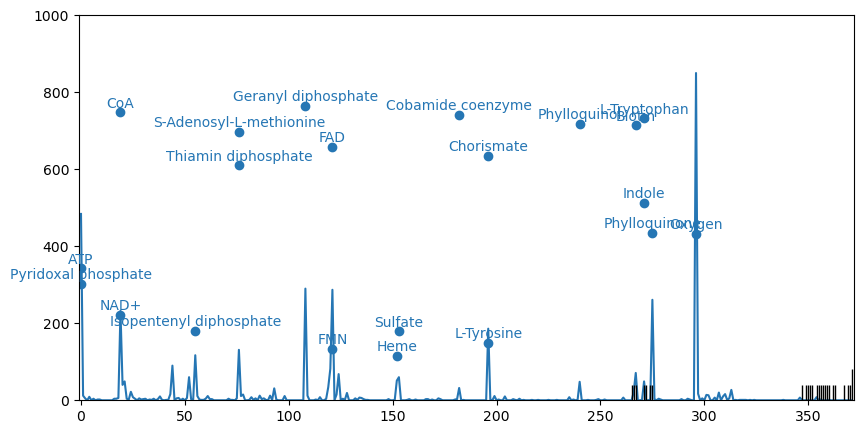

In [14]:
cpd2iter = {}
for cpd in ['C00341', 'C00463', 'C03313', 'C00032', 'C00059', 'C00251', 'C00082', 'C00078', 'C02059', 'C00120', 
          'C00018', 'C11440', 'C00002', 'C00003', 'C00010', 'C00129', 'C00068', 'C00019', 'C00016', 'C00061', 
          'C00194', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer

# plot line
plt.figure(figsize=(10, 5))
plt.plot(folditer2cpdNumFull.values(), color='#2576B4')

# Add cpd annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='#2576B4')
    plt.scatter(value, position - 5, color='#2576B4')

# Add rugplots at the top
sns.rugplot(double_injection, height=0.04, color='k')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='k')  # triple fold injection

plt.xlim([-1, len(folditer2cpdNumFull.values())])
plt.ylim([0, 1000])
# plt.savefig('Figure3A.svg', dpi=300, bbox_inches='tight')
plt.show()

# 1. Direct vs. indirect reactions
- direct := reaction has the cpd in its eqn
- indirect := reaction does NOT have the cpd in its eqn, but is unreachable when cpd in ablated

## get direct reactions from SI

In [15]:
# get 'direct' reactions from SI list of rns

direct_rns_SI_O2 = getDirectRns('C00007')
print(len(direct_rns_SI_O2))
direct_rns_SI_CoA = getDirectRns('C00010') | getDirectRns('Z00051')
print(len(direct_rns_SI_CoA))
direct_rns_SI_ATP = getDirectRns('C00002') | getDirectRns('C00008')
print(len(direct_rns_SI_ATP))
direct_rns_SI_SAM = getDirectRns('C00019') | getDirectRns('Z00041') # C00021 (SAH) is accessible before SAM (iter=0); do not include here
print(len(direct_rns_SI_SAM))
direct_rns_SI_FAD = getDirectRns('C00016') | getDirectRns('Z00013') | getDirectRns('C01352')
print(len(direct_rns_SI_FAD))
direct_rns_SI_NAD = getDirectRns('C00003') | getDirectRns('Z00032') | getDirectRns('C00004')  # Z00032 = 'NAD/NADP'
print(len(direct_rns_SI_NAD))
direct_rns_SI_NADP = getDirectRns('C00005') | getDirectRns('Z00032') | getDirectRns('C00006')
print(len(direct_rns_SI_NADP))
direct_rns_SI_PLP = getDirectRns('C00018') | getDirectRns('Z00035')
print(len(direct_rns_SI_PLP))
direct_rns_SI_ThDP = getDirectRns('C00068') | getDirectRns('Z00047')
print(len(direct_rns_SI_ThDP))
direct_rns_SI_FMN = getDirectRns('C00061') | getDirectRns('Z00014') | getDirectRns('C01847')
print(len(direct_rns_SI_FMN))
direct_rns_SI_Cobalamin = getDirectRns('Z00009')
print(len(direct_rns_SI_Cobalamin))
direct_rns_SI_AcetylCoA = getDirectRns('C00024')
print(len(direct_rns_SI_AcetylCoA))
direct_rns_SI_IPP = getDirectRns('C00129')
print(len(direct_rns_SI_IPP))

1638
659
843
581
732
1384
1389
386
103
250
50
218
50


## get unreached reactions from ablation

In [16]:
with open('../data/rns_unreached_wo/rns_unreached_wo_O2.pkl', 'rb') as file:
    unreached_O2 = pickle.load(file)
print(len(unreached_O2))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_CoA_zCoA.pkl', 'rb') as file:
    unreached_CoA = pickle.load(file)
print(len(unreached_CoA))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_ATP_ADP.pkl', 'rb') as file:
    unreached_ATP = pickle.load(file)
print(len(unreached_ATP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_SAM_zSAM.pkl', 'rb') as file:
    unreached_SAM = pickle.load(file)
print(len(unreached_SAM))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_FAD_FADH2_zFAD.pkl', 'rb') as file:
    unreached_FAD = pickle.load(file)
print(len(unreached_FAD))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_NAD_NADH_zNAD.pkl', 'rb') as file:
    unreached_NAD = pickle.load(file)
print(len(unreached_NAD))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_NADP_NADPH_zNADP.pkl', 'rb') as file:
    unreached_NADP = pickle.load(file)
print(len(unreached_NADP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_PLP_zPLP.pkl', 'rb') as file:
    unreached_PLP = pickle.load(file)
print(len(unreached_PLP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_ThDP_zThDP.pkl', 'rb') as file:
    unreached_ThDP = pickle.load(file)
print(len(unreached_ThDP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_FMN_zFMN.pkl', 'rb') as file:
    unreached_FMN = pickle.load(file)
print(len(unreached_FMN))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_IPP.pkl', 'rb') as file:
    unreached_IPP = pickle.load(file)
print(len(unreached_IPP))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_zCobalamin.pkl', 'rb') as file:
    unreached_Cobalamin = pickle.load(file)
print(len(unreached_Cobalamin))  # from ablation

with open('../data/rns_unreached_wo/rns_unreached_wo_AcetylCoA.pkl', 'rb') as file:
    unreached_AcetylCoA = pickle.load(file)
print(len(unreached_AcetylCoA))  # from ablation

1670
3788
6788
3134
2121
6591
4259
5380
1894
3590
2304
87
2911


In [17]:
# get 'indirect' reactions:
    # 1. get reactions unreachable without cofactor (cpd ablation) from actual vanilla run
    # 2. subtract 'direct' from that
# get 'direct' reactions:
    # 1. get reactions unreachable without cofactor (cpd ablation) from actual vanilla run
    # 2. get overlap with direct_reactions from SI
    # 3. check to make sure it's the same as len(direct_rns_SI_cofactor & set(rns_scope))

indirectO2 = unreached_O2 - direct_rns_SI_O2
directO2 = unreached_O2 & direct_rns_SI_O2
print('O2: ', len(indirectO2), len(directO2), len(direct_rns_SI_O2 & set(rns_scope)))

indirectATP = unreached_ATP - direct_rns_SI_ATP 
directATP = unreached_ATP & direct_rns_SI_ATP
print('ATP:',len(indirectATP), len(directATP), len(direct_rns_SI_ATP & set(rns_scope)))

indirectCoA = unreached_CoA - direct_rns_SI_CoA
directCoA = unreached_CoA & direct_rns_SI_CoA
print('CoA:', len(indirectCoA), len(directCoA), len(direct_rns_SI_CoA & set(rns_scope)))

indirectSAM = unreached_SAM - direct_rns_SI_SAM
directSAM = unreached_SAM & direct_rns_SI_SAM
print('SAM:', len(indirectSAM), len(directSAM), len(direct_rns_SI_SAM & set(rns_scope)))

indirectFAD = unreached_FAD - direct_rns_SI_FAD
directFAD = unreached_FAD & direct_rns_SI_FAD
print('FAD:', len(indirectFAD), len(directFAD), len(direct_rns_SI_FAD & set(rns_scope)))

indirectNAD = unreached_NAD - direct_rns_SI_NAD
directNAD = unreached_NAD & direct_rns_SI_NAD
print('NAD:', len(indirectNAD), len(directNAD), len(direct_rns_SI_NAD & set(rns_scope)))

indirectNADP = unreached_NADP - direct_rns_SI_NADP
directNADP = unreached_NADP & direct_rns_SI_NADP
print('NADP:', len(indirectNADP), len(directNADP), len(direct_rns_SI_NADP & set(rns_scope)))

indirectPLP = unreached_PLP - direct_rns_SI_PLP
directPLP = unreached_PLP & direct_rns_SI_PLP
print('PLP:', len(indirectPLP), len(directPLP), len(direct_rns_SI_PLP & set(rns_scope)))

indirectThDP = unreached_ThDP - direct_rns_SI_ThDP
directThDP = unreached_ThDP & direct_rns_SI_ThDP
print('ThDP:', len(indirectThDP), len(directThDP), len(direct_rns_SI_ThDP & set(rns_scope)))

indirectFMN = unreached_FMN - direct_rns_SI_FMN
directFMN = unreached_FMN & direct_rns_SI_FMN
print('FMN:', len(indirectFMN), len(directFMN), len(direct_rns_SI_FMN & set(rns_scope)))

indirectCobalamin = unreached_Cobalamin - direct_rns_SI_Cobalamin
directCobalamin = unreached_Cobalamin & direct_rns_SI_Cobalamin
print('Cobalamin:', len(indirectCobalamin), len(directCobalamin), len(direct_rns_SI_Cobalamin & set(rns_scope)))

indirectIPP = unreached_IPP - direct_rns_SI_IPP
directIPP = unreached_IPP & direct_rns_SI_IPP
print('IPP:', len(indirectIPP), len(directIPP), len(direct_rns_SI_IPP & set(rns_scope)))

indirectAcetylCoA = unreached_AcetylCoA - direct_rns_SI_AcetylCoA
directAcetylCoA = unreached_AcetylCoA & direct_rns_SI_AcetylCoA
print('AcetylCoA:', len(indirectAcetylCoA), len(directAcetylCoA), len(direct_rns_SI_AcetylCoA & set(rns_scope)))

O2:  823 847 847
ATP: 6142 646 646
CoA: 3325 463 463
SAM: 2800 334 334
FAD: 1631 490 490
NAD: 5716 875 875
NADP: 3400 859 859
PLP: 5032 348 348
ThDP: 1798 96 96
FMN: 3411 179 179
Cobalamin: 50 37 37
IPP: 2255 49 49
AcetylCoA: 2747 164 164


#### what if we ignore Z cpds?

In [18]:
# ignore Z compounds
print('      C+Z  C')
print('-------------')

direct_rns_SI_CoA_C = getDirectRns('C00010')
print('CoA: ',len(direct_rns_SI_CoA), len(direct_rns_SI_CoA_C))
direct_rns_SI_ATP_C = getDirectRns('C00002')
print('ATP: ',len(direct_rns_SI_ATP), len(direct_rns_SI_ATP_C))
direct_rns_SI_SAM_C = getDirectRns('C00019')
print('SAM: ',len(direct_rns_SI_SAM), len(direct_rns_SI_SAM_C))
direct_rns_SI_FAD_C = getDirectRns('C00016')
print('FAD: ',len(direct_rns_SI_FAD), len(direct_rns_SI_FAD_C))
direct_rns_SI_NAD_C = getDirectRns('C00003')
print('NAD: ',len(direct_rns_SI_NAD), len(direct_rns_SI_NAD_C))
direct_rns_SI_NADP_C = getDirectRns('C00005')
print('NADP:',len(direct_rns_SI_NADP), len(direct_rns_SI_NADP_C))
direct_rns_SI_PLP_C = getDirectRns('C00018')
print('PLP: ',len(direct_rns_SI_PLP), len(direct_rns_SI_PLP_C))
direct_rns_SI_ThDP_C = getDirectRns('C00068')
print('ThDP:',len(direct_rns_SI_ThDP), len(direct_rns_SI_ThDP_C))
direct_rns_SI_FMN_C = getDirectRns('C00061')
print('FMN: ',len(direct_rns_SI_FMN), len(direct_rns_SI_FMN_C))

      C+Z  C
-------------
CoA:  659 638
ATP:  843 796
SAM:  581 564
FAD:  732 93
NAD:  1384 1078
NADP: 1389 1080
PLP:  386 15
ThDP: 103 28
FMN:  250 72


In [19]:
directO2_C = unreached_O2 & direct_rns_SI_O2
print('O2: ', len(directO2), len([rn for rn in directO2 if rn2rev[rn]]))
[rn for rn in directO2 if rn2rev[rn]]

# only 1 O2 reactions is 'reversible'!

O2:  847 1


['R09503_vX']

In [20]:
print('     C+Z C rev n_rev')
print('-------------------------')

print('O2:  ', ' - ', len(directO2), len([rn for rn in directO2 if rn2rev[rn]]), len([rn for rn in directO2 if not rn2rev[rn]]))
directCoA_C = unreached_CoA & direct_rns_SI_CoA_C
print('CoA: ', len(directCoA), len(directCoA_C), len([rn for rn in directCoA_C if rn2rev[rn]]), len([rn for rn in directCoA_C if not rn2rev[rn]]))
directATP_C = unreached_ATP & direct_rns_SI_ATP_C
print('ATP: ', len(directATP), len(directATP_C), len([rn for rn in directATP_C if rn2rev[rn]]), len([rn for rn in directATP_C if not rn2rev[rn]]))
directSAM_C = unreached_SAM & direct_rns_SI_SAM_C
print('SAM: ', len(directSAM), len(directSAM_C), len([rn for rn in directSAM_C if rn2rev[rn]]), len([rn for rn in directSAM_C if not rn2rev[rn]]))
directFAD_C = unreached_FAD & direct_rns_SI_FAD_C
print('FAD: ', len(directFAD), len(directFAD_C), len([rn for rn in directFAD_C if rn2rev[rn]]), len([rn for rn in directFAD_C if not rn2rev[rn]]))
directNAD_C = unreached_NAD & direct_rns_SI_NAD_C
print('NAD: ', len(directNAD), len(directNAD_C), len([rn for rn in directNAD_C if rn2rev[rn]]), len([rn for rn in directNAD_C if not rn2rev[rn]]))
directNADP_C = unreached_NADP & direct_rns_SI_NADP_C
print('NADP:', len(directNADP), len(directNADP_C), len([rn for rn in directNADP_C if rn2rev[rn]]), len([rn for rn in directNADP_C if not rn2rev[rn]]))
directPLP_C = unreached_PLP & direct_rns_SI_PLP_C
print('PLP: ', len(directPLP), len(directPLP_C), len([rn for rn in directPLP_C if rn2rev[rn]]), len([rn for rn in directPLP_C if not rn2rev[rn]]))
directThDP_C = unreached_ThDP & direct_rns_SI_ThDP_C
print('ThDP: ', len(directThDP), len(directThDP_C), len([rn for rn in directThDP_C if rn2rev[rn]]), len([rn for rn in directThDP_C if not rn2rev[rn]]))
directFMN_C = unreached_FMN & direct_rns_SI_FMN_C
print('FMN: ', len(directFMN), len(directFMN_C), len([rn for rn in directFMN_C if rn2rev[rn]]), len([rn for rn in directFMN_C if not rn2rev[rn]]))

     C+Z C rev n_rev
-------------------------
O2:    -  847 1 846
CoA:  463 445 351 94
ATP:  646 606 559 47
SAM:  334 320 291 29
FAD:  490 53 45 8
NAD:  875 661 538 123
NADP: 859 644 472 172
PLP:  348 15 8 7
ThDP:  96 28 20 8
FMN:  179 40 25 15


## calculate fraction of reactions that are direct cofactor-utilizing 

In [23]:
# make x2rn with the same scope as our simulations

x2rn_scope = {}
for x, rns in x2rn.items():
    scope_rns = []
    for rn in rns:
        if rn in rns_scope:  # check if rn appears in our simulations
            scope_rns.append(rn)
    x2rn_scope[x] = scope_rns

In [24]:
def makeCofactorDicts(direct_rns, indirect_rns):
    
    # x: {'direct': [str], 'indirect': [str], 'total': [str]}
    x2rn_cofactor = {}
    for x, rns in x2rn_scope.items():
        fracdict = {'direct':[], 'indirect':[], 'total':[]}
        for rn in rns:
            if rn in direct_rns:
                fracdict['direct'].append(rn)
            if rn in indirect_rns:
                fracdict['indirect'].append(rn)
            fracdict['total'].append(rn)
        x2rn_cofactor[x] = fracdict
    
    # x: [float, float, float]
    x2rnFrac_cofactor = {}
    for x, d in x2rn_cofactor.items():
        dir_total = len(d['direct']) / len(d['total'])
        ind_total = len(d['indirect']) / len(d['total'])
        dir_ind_total = len((set(d['direct']) | set(d['indirect']))) / len(d['total'])
        x2rnFrac_cofactor[x] = [dir_total, ind_total, dir_ind_total]
    
    return x2rn_cofactor, x2rnFrac_cofactor

In [25]:
x2rn_O2, x2rnFrac_O2 = makeCofactorDicts(directO2, indirectO2)
x2rn_ATP, x2rnFrac_ATP = makeCofactorDicts(directATP, indirectATP)
x2rn_CoA, x2rnFrac_CoA = makeCofactorDicts(directCoA, indirectCoA)
x2rn_SAM, x2rnFrac_SAM = makeCofactorDicts(directSAM, indirectSAM)
x2rn_FAD, x2rnFrac_FAD = makeCofactorDicts(directFAD, indirectFAD)

x2rn_NAD, x2rnFrac_NAD = makeCofactorDicts(directNAD, indirectNAD)
x2rn_NADP, x2rnFrac_NADP = makeCofactorDicts(directNADP, indirectNADP)
x2rn_PLP, x2rnFrac_PLP = makeCofactorDicts(directPLP, indirectPLP)
x2rn_ThDP, x2rnFrac_ThDP = makeCofactorDicts(directThDP, indirectThDP)

x2rn_FMN, x2rnFrac_FMN = makeCofactorDicts(directFMN, indirectFMN)
x2rn_IPP, x2rnFrac_IPP = makeCofactorDicts(directIPP, indirectIPP)
x2rn_Cobalamin, x2rnFrac_Cobalamin = makeCofactorDicts(directCobalamin, indirectCobalamin)
x2rn_AcetylCoA, x2rnFrac_AcetylCoA = makeCofactorDicts(directAcetylCoA, indirectAcetylCoA)

## plot fractions against mean fold order (x2foAve)

In [29]:
x2rnFrac_O2_0 = {x:values[0] for x, values in x2rnFrac_O2.items()}
x2rnFrac_O2_1 = {x:values[1] for x, values in x2rnFrac_O2.items()}

x2rnFrac_ATP_0 = {x:values[0] for x, values in x2rnFrac_ATP.items()}
x2rnFrac_ATP_1 = {x:values[1] for x, values in x2rnFrac_ATP.items()}

x2rnFrac_CoA_0 = {x:values[0] for x, values in x2rnFrac_CoA.items()}
x2rnFrac_CoA_1 = {x:values[1] for x, values in x2rnFrac_CoA.items()}

x2rnFrac_SAM_0 = {x:values[0] for x, values in x2rnFrac_SAM.items()}
x2rnFrac_SAM_1 = {x:values[1] for x, values in x2rnFrac_SAM.items()}

x2rnFrac_FAD_0 = {x:values[0] for x, values in x2rnFrac_FAD.items()}
x2rnFrac_FAD_1 = {x:values[1] for x, values in x2rnFrac_FAD.items()}

x2rnFrac_NAD_0 = {x:values[0] for x, values in x2rnFrac_NAD.items()}
x2rnFrac_NAD_1 = {x:values[1] for x, values in x2rnFrac_NAD.items()}

x2rnFrac_NADP_0 = {x:values[0] for x, values in x2rnFrac_NADP.items()}
x2rnFrac_NADP_1 = {x:values[1] for x, values in x2rnFrac_NADP.items()}

x2rnFrac_PLP_0 = {x:values[0] for x, values in x2rnFrac_PLP.items()}
x2rnFrac_PLP_1 = {x:values[1] for x, values in x2rnFrac_PLP.items()}

x2rnFrac_ThDP_0 = {x:values[0] for x, values in x2rnFrac_ThDP.items()}
x2rnFrac_ThDP_1 = {x:values[1] for x, values in x2rnFrac_ThDP.items()}

x2rnFrac_FMN_0 = {x:values[0] for x, values in x2rnFrac_FMN.items()}
x2rnFrac_FMN_1 = {x:values[1] for x, values in x2rnFrac_FMN.items()}

x2rnFrac_IPP_0 = {x:values[0] for x, values in x2rnFrac_IPP.items()}
x2rnFrac_IPP_1 = {x:values[1] for x, values in x2rnFrac_IPP.items()}

x2rnFrac_Cobalamin_0 = {x:values[0] for x, values in x2rnFrac_Cobalamin.items()}
x2rnFrac_Cobalamin_1 = {x:values[1] for x, values in x2rnFrac_Cobalamin.items()}

x2rnFrac_AcetylCoA_0 = {x:values[0] for x, values in x2rnFrac_AcetylCoA.items()}
x2rnFrac_AcetylCoA_1 = {x:values[1] for x, values in x2rnFrac_AcetylCoA.items()}

In [152]:
# dict2csv(x2rnFrac_O2, '../data/assets/xgroup2/x2O2rnFrac_scope.csv')

02 (0.26497714053965304, '8.685304e-08')


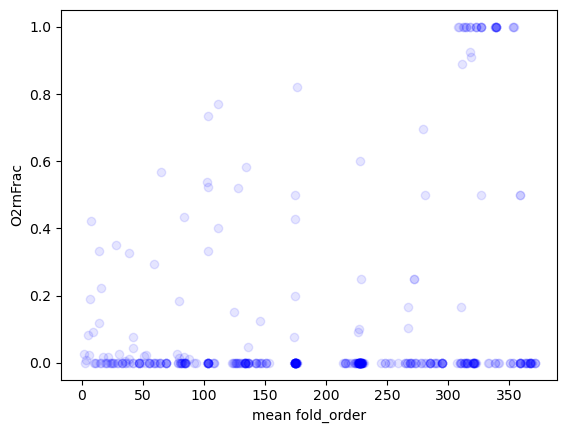

ATP (-0.014093526063696472, '7.797960e-01')


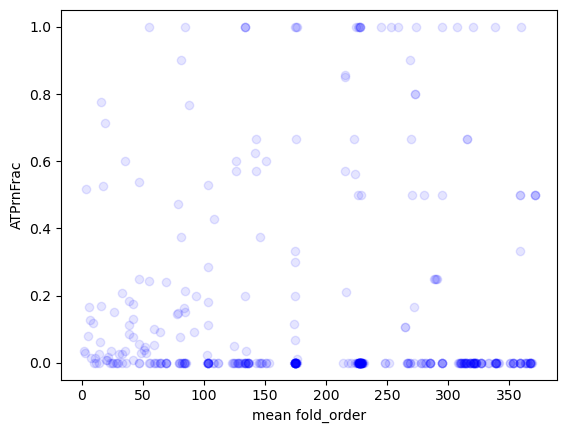

CoA (0.007932391516128599, '8.749642e-01')


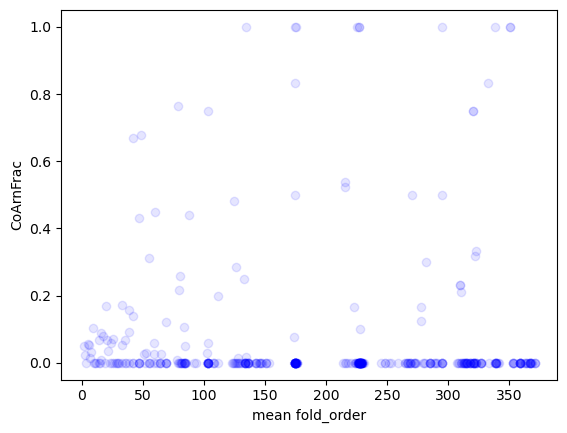

SAM (0.0732854527648617, '1.454728e-01')


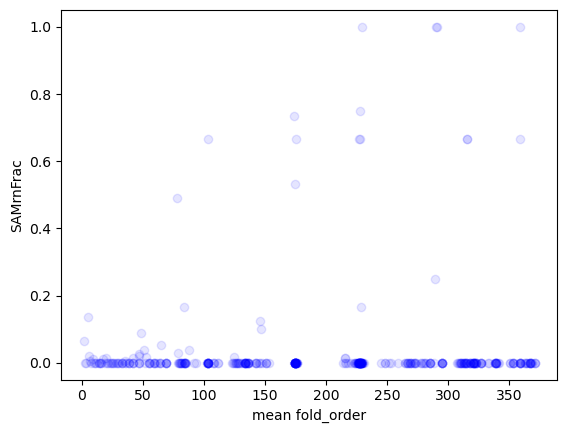

FAD (0.07302791314496607, '1.468967e-01')


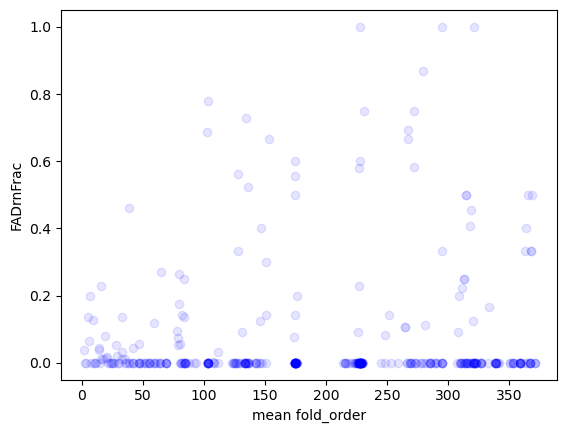

In [32]:
print('02', pearson(x2foMean, x2rnFrac_O2_0))
scatter(x2foMean, x2rnFrac_O2_0, x_axis='mean fold_order', y_axis='O2rnFrac')

print('ATP', pearson(x2foMean, x2rnFrac_ATP_0))
scatter(x2foMean, x2rnFrac_ATP_0, x_axis='mean fold_order', y_axis='ATPrnFrac')

print('CoA', pearson(x2foMean, x2rnFrac_CoA_0))
scatter(x2foMean, x2rnFrac_CoA_0, x_axis='mean fold_order', y_axis='CoArnFrac')

print('SAM', pearson(x2foMean, x2rnFrac_SAM_0))
scatter(x2foMean, x2rnFrac_SAM_0, x_axis='mean fold_order', y_axis='SAMrnFrac')

print('FAD', pearson(x2foMean, x2rnFrac_FAD_0))
scatter(x2foMean, x2rnFrac_FAD_0, x_axis='mean fold_order', y_axis='FADrnFrac')

## get 'direct folds' that have cofactors in equation

In [33]:
direct_folds_O2 = [x for x,v in x2rnFrac_O2.items() if v[0] > 0]
print(len(direct_folds_O2))
direct_folds_ATP = [x for x,v in x2rnFrac_ATP.items() if v[0] > 0]
print(len(direct_folds_ATP))
direct_folds_CoA = [x for x,v in x2rnFrac_CoA.items() if v[0] > 0]
print(len(direct_folds_CoA))
direct_folds_SAM = [x for x,v in x2rnFrac_SAM.items() if v[0] > 0]
print(len(direct_folds_SAM))
direct_folds_FAD = [x for x,v in x2rnFrac_FAD.items() if v[0] > 0]
print(len(direct_folds_FAD))
direct_folds_NAD = [x for x,v in x2rnFrac_NAD.items() if v[0] > 0]
print(len(direct_folds_NAD))
direct_folds_NADP = [x for x,v in x2rnFrac_NADP.items() if v[0] > 0]
print(len(direct_folds_NADP))
direct_folds_PLP = [x for x,v in x2rnFrac_PLP.items() if v[0] > 0]
print(len(direct_folds_PLP))
direct_folds_ThDP = [x for x,v in x2rnFrac_ThDP.items() if v[0] > 0]
print(len(direct_folds_ThDP))
direct_folds_IPP = [x for x,v in x2rnFrac_IPP.items() if v[0] > 0]
print(len(direct_folds_IPP))
direct_folds_FMN = [x for x,v in x2rnFrac_FMN.items() if v[0] > 0]
print(len(direct_folds_FMN))
direct_folds_Cobalamin = [x for x,v in x2rnFrac_Cobalamin.items() if v[0] > 0]
print(len(direct_folds_Cobalamin))
direct_folds_AcetylCoA = [x for x,v in x2rnFrac_AcetylCoA.items() if v[0] > 0]
print(len(direct_folds_AcetylCoA))

88
132
79
40
89
127
120
41
22
8
75
16
63


# 2. ETU (Emerge to Use) folds

In [34]:
# preATP cumiter

df_folds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_cumiter_preATP.csv', index_col=0)
df_cpds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_cumiter_preATP.csv', index_col=0)
df_rns_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_cumiter_preATP.csv', index_col=0)
df_rules_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_cumiter_preATP.csv', index_col=0)

In [35]:
# NONE cumiter

# df_folds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_cumiter_NONE.csv', index_col=0)
# df_cpds_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_cumiter_NONE.csv', index_col=0)
# df_rns_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_cumiter_NONE.csv', index_col=0)
# df_rules_cumiter = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_cumiter_NONE.csv', index_col=0)

In [36]:
# this takes time
# collect cumiter2rules for all 1000 runs

cumiter2rules_all_runs = {}
for run in df_rules_cumiter:
    cumiter2rules = {}
    for rule, i in df_rules_cumiter[run].items():
        if i not in cumiter2rules:
            cumiter2rules[i] = [eval(rule)]  # convert string into tuple with 'eval'
        else:
            cumiter2rules[i].append(eval(rule))
    cumiter2rules_all_runs[run] = cumiter2rules

### helper function to differentiate cofactor 'using' and 'producing' reactions

In [37]:
# helper function to return reactions that 'use' or 'produce' given cofactor when discovered
# if reversible, return reac_iters and prod_iters to compare with fold-cumiter in main function

def getUsingProducingRns(run, cofactor, direct_cofactor_rns):
    cofactor_using = []
    both = {}
    cofactor_producing = []

    if cofactor.startswith('Z'):
        print('this function cannot be used with Z compounds, since they are not consumed!')
        return None
    
    for rn in direct_cofactor_rns:

        if rn2direction[rn] == 'forward':
            if cofactor in rn2prod[rn]: # forward AND cpd is in prod
                cofactor_producing.append(rn) 
            else:
                cofactor_using.append(rn)
        elif rn2direction[rn] == 'reverse':
            if cofactor in rn2reac[rn]: # reverse AND cpd is in reac
                cofactor_producing.append(rn) 
            else:
                cofactor_using.append(rn)
        else:  # reversible 
            reac_iters = [df_cpds_cumiter[run][c] for c in rn2reac[rn]]
            prod_iters = [df_cpds_cumiter[run][c] for c in rn2prod[rn]]

            # return max cumiters of reac and prod to be compared to 'fold cumiter' later
            both[rn] = (max(reac_iters), max(prod_iters))
            
    return cofactor_using, both, cofactor_producing

# example
run = '87452'
cofactor = 'C00007'
direct_cofactor_rns = directO2
using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rns)
print(len(directO2), len(using), len(both), len(producing))

847 826 1 20


In [39]:
# check major cofactors
cid2directRns = {'C00007': directO2, 'C00002': directATP, 'C00010': directCoA, 'C00019': directSAM, 'C00016': directFAD, 'C00003': directNAD, 'C00005': directNADP, 'C00018': directPLP, 'C00068': directThDP, 'C00061': directFMN, 'C00129': directIPP, 'C00024': directAcetylCoA}
run = '87452'
for cid, direct_cofactor_rns in cid2directRns.items():
    using, both, producing = getUsingProducingRns(run, cid, direct_cofactor_rns)
    print(cid, len(direct_cofactor_rns), len(using), len(both), len(producing))

C00007 847 826 1 20
C00002 646 43 595 8
C00010 463 18 368 77
C00019 334 32 302 0
C00016 490 298 188 4
C00003 875 136 648 91
C00005 859 258 582 19
C00018 348 71 272 5
C00068 96 20 69 7
C00061 179 75 94 10
C00129 49 34 14 1
C00024 164 14 147 3


### getETC_UC: function to collect folds that 'emerge to use' a given cpd

In [44]:
# for Z cpds  (do not differentiate use vs. produce)
def getETU_UC(direct_cofactor_rn_set, direct_cofactor_fold_set=None):
    
    recruited_folds_allruns = []
    for run, cumiter2rules in cumiter2rules_all_runs.items():
        
        # collect a list of rnRules discovered at the same time as fold injection
        x2first_rules = {} 
        for x, i in df_folds_cumiter[run].items():
            if direct_cofactor_fold_set == None:  # no fold_set given
                if x != 'fold_independent':
                    x2first_rules[x] = cumiter2rules[i]
            else:
                if x in direct_cofactor_fold_set:  # only look at folds we already know have cofactor-using reactions
                    x2first_rules[x] = cumiter2rules[i]
                
        # A. LOOSE: ETU if ANY reaction uses the cofactor
        recruited_folds = set()
        for x, rules in x2first_rules.items():
            for rule in rules:
                if rule[0] in direct_cofactor_rn_set:  # direct cofactor rns 
                    recruited_folds.add(x)
        
        # B. STRICT: ETU if ALL reactions use the cofactor
        # recruited_folds = set()
        # for x, rules in x2first_rules.items():
        #     count = 0
        #     # count num of cofactor reactions
        #     for rule in rules:
        #         if rule[0] in direct_cofactor_rn_set:  # direct cofactor rns 
        #             count += 1
        #     if count == len(rules):  # if all reactions use the cofactor
        #         recruited_folds.add(x)        

        # collect data from one run
        recruited_folds_allruns.append(recruited_folds)

    # tally of all folds
    l = []  
    for run in recruited_folds_allruns:
        for x in run:
            l.append(x)
    
    # divide based on threshold
    emerged_to_use = set()
    unclassified = set()
    for x in set(l):
#         print(l.count(x)/len(df_rules_cumiter.columns))
        if l.count(x)/len(df_rules_cumiter.columns) >= 0.75:  # change threshold here
            emerged_to_use.add(x)
        else:
            unclassified.add(x)

    # return the set of folds 'recruited for' the cofactor
    return emerged_to_use, unclassified

In [45]:
# for C cpds (differentiate use vs. produce)

def getETU_UC_C(cofactor, direct_cofactor_rn_set, direct_cofactor_fold_set=None):
    recruited_folds_allruns = []
    # just use one run to get using/producing reactions
    run = '87452'
    using, both, producing = getUsingProducingRns(run, cofactor, direct_cofactor_rn_set)
    
    for run, cumiter2rules in cumiter2rules_all_runs.items():
        
        # collect a list of rnRules discovered at the same time as fold injection
        x2first_rules = {} 
        for x, i in df_folds_cumiter[run].items():
            if direct_cofactor_fold_set == None:  # no fold_set given
                if x != 'fold_independent':
                    x2first_rules[x] = cumiter2rules[i]
            else:
                if x in direct_cofactor_fold_set:  # only look at folds we already know have cofactor-using reactions
                    x2first_rules[x] = cumiter2rules[i]
                
        # go through the reactions and determine their direction => collect cases where the fold 'used' the cofactor
        
        # A. LOOSE: ETU if ANY reaction uses the cofactor
        recruited_folds = set()
        for x, rules in x2first_rules.items():
            for rule in rules:
                if rule[0] in using:  # direct cofactor USING rns 
                    recruited_folds.add(x)
                if rule[0] in both:  # reversible
                    recruited_folds.add(x)
        
        # B. STRICT: ETU if ALL reactions use the cofactor
        # recruited_folds = set()
        # for x, rules in x2first_rules.items():
        #     count = 0
        #     for rule in rules:
        #         # differentiate usage vs. production (reactant vs. product)
        #         if rule[0] in using:  # direct cofactor USING rns 
        #             count += 1
        #         if rule[0] in both:
        #             # also add to recruit
        #             count += 1      
        #     if count == len(rules):
        #         recruited_folds.add(x)

        # collect data from one run
        recruited_folds_allruns.append(recruited_folds)

    # tally of all folds
    l = []  
    for run in recruited_folds_allruns:
        for x in run:
            l.append(x)
    
    # divide based on threshold
    emerged_to_use = set()
    unclassified = set()
    
    for x in set(l):
#         print(l.count(x)/len(df_rules_cumiter.columns))
        if l.count(x)/len(df_rules_cumiter.columns) >= 0.75:  # change threshold here
            emerged_to_use.add(x)
        else:
            unclassified.add(x)

    # return the set of folds 'recruited for' the cofactor
    return emerged_to_use, unclassified

In [46]:
ETU_O2, UC_O2 = getETU_UC(directO2, direct_folds_O2)
print(len(ETU_O2), len(UC_O2))
ETU_O2_C, UC_O2_C = getETU_UC_C('C00007', directO2, direct_folds_O2)
print(len(ETU_O2_C), len(UC_O2_C))

33 0
31 0


In [47]:
ETU_O2 - ETU_O2_C

{'192', '228'}

In [48]:
# direct recruitment defined by cumiter; this takes longer

# using C (strict)
ETU_O2, UC_O2 = getETU_UC_C('C00007', directO2, direct_folds_O2)  # using the alternative method only looking at C compound
print('O2:  ', len(ETU_O2), len(UC_O2))
# using C+Z (loose)
# ETU_O2, UC_O2 = getETU_UC(directO2, direct_folds_O2)  # using the alternative method only looking at C compound
# print('O2:  ', len(ETU_O2), len(UC_O2))


# using C+Z 
# ETU_ATP, UC_ATP = getETU_UC(directATP, direct_folds_ATP)
# print('ATP: ', len(ETU_ATP), len(UC_ATP))
# ETU_CoA, UC_CoA = getETU_UC(directCoA, direct_folds_CoA)
# print('CoA: ', len(ETU_CoA), len(UC_CoA))
# ETU_SAM, UC_SAM = getETU_UC(directSAM, direct_folds_SAM)
# print('SAM: ', len(ETU_SAM), len(UC_SAM))
# ETU_FAD, UC_FAD = getETU_UC(directFAD, direct_folds_FAD)
# print('FAD: ', len(ETU_FAD), len(UC_FAD))
# ETU_NAD, UC_NAD = getETU_UC(directNAD, direct_folds_NAD)
# print('NAD: ', len(ETU_NAD), len(UC_NAD))
# ETU_NADP, UC_NADP = getETU_UC(directNADP, direct_folds_NADP)
# print('NADP:', len(ETU_NADP), len(UC_NADP))
# ETU_PLP, UC_PLP = getETU_UC(directPLP, direct_folds_PLP)
# print('PLP: ', len(ETU_PLP), len(UC_PLP))
# ETU_ThDP, UC_ThDP = getETU_UC(directThDP, direct_folds_ThDP)
# print('ThDP:', len(ETU_ThDP), len(UC_ThDP))
# ETU_IPP, UC_IPP = getETU_UC(directIPP, direct_folds_IPP)
# print('IPP: ', len(ETU_IPP), len(UC_IPP))
# ETU_FMN, UC_FMN = getETU_UC(directFMN, direct_folds_FMN)
# print('FMN: ', len(ETU_FMN), len(UC_FMN))
# ETU_Cobalamin, UC_Cobalamin = getETU_UC(directCobalamin, direct_folds_Cobalamin)
# print('Cobalamin: ', len(ETU_Cobalamin), len(UC_Cobalamin))
# ETU_AcetylCoA, UC_AcetylCoA = getETU_UC(directAcetylCoA, direct_folds_AcetylCoA)
# print('AcetylCoA: ', len(ETU_AcetylCoA), len(UC_AcetylCoA))

O2:   31 0


### colored scatterplot => pie chart

In [49]:
cpd2foMean = {}
cpd2foStd = {}
for x in df_cpds_folditer.index:
    cpd2foMean[x] = np.mean(df_cpds_folditer.loc[x])
    cpd2foStd[x] = np.std(df_cpds_folditer.loc[x])

In [50]:
cpd2foMean['C00007']

307.151

In [51]:
def cofactorScatter(cid, title, x2rnFrac_cofactor_0, etu):
    print(title, pearson(x2foMean, x2rnFrac_cofactor_0))
    dict1 = x2foMean
    dict2 = x2rnFrac_cofactor_0
    valid_keys, data1, data2 = todata(dict1, dict2)

    colors = ['r' if key in etu else 'b' for key in valid_keys]

    plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.1, label='Data Points', zorder=2)
    plt.axvline(x=cpd2foMean[cid], color='k', ls='--', lw=1)
    plt.xlabel('mean fold_order')
    plt.ylabel(f'{title} rn fraction')
    
    # plt.savefig('cofactorScatter.svg', dpi=300, bbox_inches='tight')
    plt.show()

O2 (0.26497714053965304, '8.685304e-08')


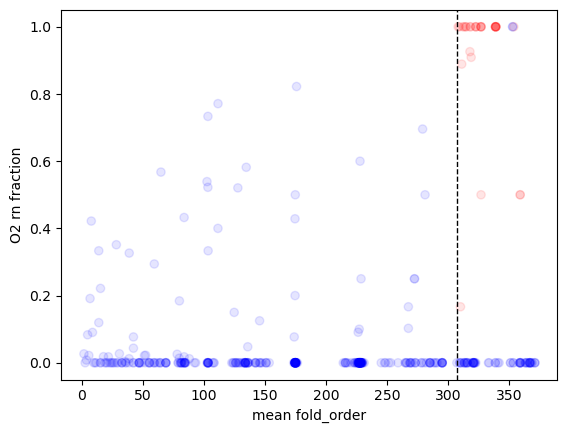

In [53]:
cofactorScatter('C00007', 'O2', x2rnFrac_O2_0, ETU_O2)
# cofactorScatter('C00019', 'SAM', x2rnFrac_SAM_0, ETU_SAM)
# cofactorScatter('C00002', 'ATP', x2rnFrac_ATP_0, ETU_ATP)
# cofactorScatter('C00010', 'CoA', x2rnFrac_CoA_0, ETU_CoA)
# cofactorScatter('C00016', 'FAD', x2rnFrac_FAD_0, ETU_FAD)

In [54]:
def getCategories(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc):
    emerge_to_use = set()  
    learn_to_use = set()
    unclassified = set()
    
    never_use_direct = set() # direct/total == 0
    never_use = set()  # direct/total == 0; indirect/total == 0; 'orthogonal'
    indirect_use = set() # direct/total == 0; indirect/total > 0

    for x, frac in x2rnFrac_cofactor_0.items():  # direct/total
        if frac == 0:
             never_use_direct.add(x)
        else:
            if x in etu:
                emerge_to_use.add(x)
            elif x in unc:
                unclassified.add(x)
            else:
                learn_to_use.add(x)  # here we don't check the direction...
    
    for x, frac in x2rnFrac_cofactor_1.items():  # indirect/total
        if x in never_use_direct and frac == 0:
             never_use.add(x)
        else:
            indirect_use.add(x)
    
    indirect_use_only = indirect_use - (emerge_to_use|learn_to_use|unclassified)
    return never_use, indirect_use_only, emerge_to_use, unclassified, learn_to_use

In [55]:
def drawPie(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc, title):
    never_use, indirect_use, emerge_to_use, unclassified, learn_to_use = getCategories(x2rnFrac_cofactor_0, x2rnFrac_cofactor_1, etu, unc)
    
    labels = ['never_use', 'indirect_use', 'learn_to_use', 'unclassified', 'emerge_to_use']
    values = [len(never_use), len(indirect_use), len(learn_to_use), len(unclassified), len(emerge_to_use)]
    colors = ['gray', 'lightgray', 'lightblue', '#f94449', 'red']
#     hatches = ['', '', '', '.', '']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(values, colors=colors, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
    plt.title(f'{title} n={sum(values)}')
    plt.savefig(f'piechart_cofactor_{title}.svg', dpi=300, bbox_inches='tight')
    plt.show()

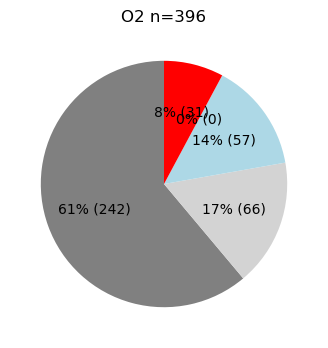

In [56]:
drawPie(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2, 'O2')
# drawPie(x2rnFrac_ATP_0, x2rnFrac_ATP_1, ETU_ATP, UC_ATP, 'ATP')
# drawPie(x2rnFrac_SAM_0, x2rnFrac_SAM_1, ETU_SAM, UC_SAM, 'SAM')
# drawPie(x2rnFrac_CoA_0, x2rnFrac_CoA_1, ETU_CoA, UC_CoA, 'CoA')
# drawPie(x2rnFrac_FAD_0, x2rnFrac_FAD_1, ETU_FAD, UC_FAD, 'FAD')

In [165]:
never_use, indirect_use, emerge_to_use, unclassified, learn_to_use = getCategories(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2)
print(len(never_use))
print(len(indirect_use))
print(len(emerge_to_use))
print(len(unclassified))
print(len(learn_to_use))

242
66
31
0
57


### stackplots instead

In [174]:
# Define categories, values, and colors
categories = ['never_use', 'indirect_use', 'emerge_to_use', 'unclassified', 'learn_to_use']
colors = ['gray', 'skyblue', 'red', '#f94449', 'pink']

In [175]:
NU_O2, IU_O2, ETU_O2, UC_O2, LTU_O2 =getCategories(x2rnFrac_O2_0, x2rnFrac_O2_1, ETU_O2, UC_O2)
NU_ATP, IU_ATP, ETU_ATP, UC_ATP, LTU_ATP =getCategories(x2rnFrac_ATP_0, x2rnFrac_ATP_1, ETU_ATP, UC_ATP)
NU_SAM, IU_SAM, ETU_SAM, UC_SAM, LTU_SAM =getCategories(x2rnFrac_SAM_0, x2rnFrac_SAM_1, ETU_SAM, UC_SAM)
NU_CoA, IU_CoA, ETU_CoA, UC_CoA, LTU_CoA =getCategories(x2rnFrac_CoA_0, x2rnFrac_CoA_1, ETU_CoA, UC_CoA)
NU_FAD, IU_FAD, ETU_FAD, UC_FAD, LTU_FAD =getCategories(x2rnFrac_FAD_0, x2rnFrac_FAD_1, ETU_FAD, UC_FAD)

NU_NAD, IU_NAD, ETU_NAD, UC_NAD, LTU_NAD =getCategories(x2rnFrac_NAD_0, x2rnFrac_NAD_1, ETU_NAD, UC_NAD)
NU_NADP, IU_NADP, ETU_NADP, UC_NADP, LTU_NADP =getCategories(x2rnFrac_NADP_0, x2rnFrac_NADP_1, ETU_NADP, UC_NADP)
NU_PLP, IU_PLP, ETU_PLP, UC_PLP, LTU_PLP =getCategories(x2rnFrac_PLP_0, x2rnFrac_PLP_1, ETU_PLP, UC_PLP)
NU_ThDP, IU_ThDP, ETU_ThDP, UC_ThDP, LTU_ThDP =getCategories(x2rnFrac_ThDP_0, x2rnFrac_ThDP_1, ETU_ThDP, UC_ThDP)

NU_IPP, IU_IPP, ETU_IPP, UC_IPP, LTU_IPP =getCategories(x2rnFrac_IPP_0, x2rnFrac_IPP_1, ETU_IPP, UC_IPP)
NU_FMN, IU_FMN, ETU_FMN, UC_FMN, LTU_FMN =getCategories(x2rnFrac_FMN_0, x2rnFrac_FMN_1, ETU_FMN, UC_FMN)
NU_Cobalamin, IU_Cobalamin, ETU_Cobalamin, UC_Cobalamin, LTU_Cobalamin =getCategories(x2rnFrac_Cobalamin_0, x2rnFrac_Cobalamin_1, ETU_Cobalamin, UC_Cobalamin)
NU_AcetylCoA, IU_AcetylCoA, ETU_AcetylCoA, UC_AcetylCoA, LTU_AcetylCoA =getCategories(x2rnFrac_AcetylCoA_0, x2rnFrac_AcetylCoA_1, ETU_AcetylCoA, UC_AcetylCoA)

In [176]:
print('    ETU   LTU   UC ')
print('------------------------')

print('O2  ', len(ETU_O2), '  ', len(LTU_O2), '  ', len(UC_O2))
print('ATP ', len(ETU_ATP), '  ', len(LTU_ATP), '  ', len(UC_ATP))
print('CoA  ', len(ETU_CoA), '  ', len(LTU_CoA), '  ', len(UC_CoA))
print('SAM ', len(ETU_SAM), '  ', len(LTU_SAM), '  ', len(UC_SAM))
print('FAD ', len(ETU_FAD), '  ', len(LTU_FAD), '  ', len(UC_FAD))
print('NAD ', len(ETU_NAD), '  ', len(LTU_NAD), '  ', len(UC_NAD))
print('NADP', len(ETU_NADP), '  ', len(LTU_NADP), '  ', len(UC_NADP))
print('PLP ', len(ETU_PLP), '  ', len(LTU_PLP), '  ', len(UC_PLP))
print('ThDP ', len(ETU_ThDP), '  ', len(LTU_ThDP), '  ', len(UC_ThDP))

    ETU   LTU   UC 
------------------------
O2   24    64    0
ATP  34    95    3
CoA   15    62    2
SAM  8    32    0
FAD  10    79    0
NAD  12    114    1
NADP 14    104    2
PLP  8    33    0
ThDP  2    20    0


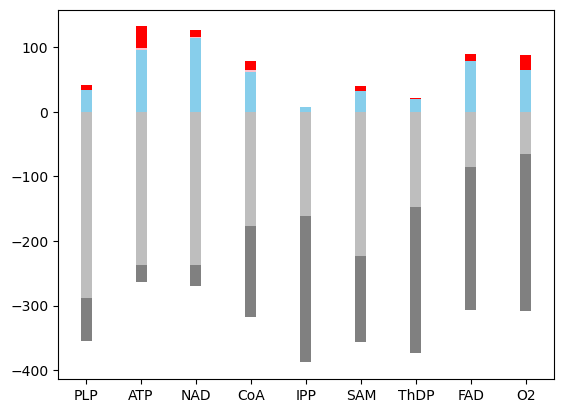

In [177]:
# a = [-len(IU_PLP), -len(IU_ATP), -len(IU_NAD), -len(IU_NADP), -len(IU_CoA), -len(IU_AcetylCoA), -len(IU_IPP), -len(IU_SAM), -len(IU_ThDP), -len(IU_FAD), -len(IU_FMN), -len(IU_Cobalamin), -len(IU_O2)] 
# b = [-len(NU_PLP), -len(NU_ATP), -len(NU_NAD), -len(NU_NADP), -len(NU_CoA), -len(NU_AcetylCoA), -len(NU_IPP), -len(NU_SAM), -len(NU_ThDP), -len(NU_FAD),  -len(NU_FMN), -len(NU_Cobalamin), -len(NU_O2)]  
# c = [len(LTU_PLP), len(LTU_ATP), len(LTU_NAD), len(LTU_NADP), len(LTU_CoA), len(LTU_AcetylCoA), len(LTU_IPP), len(LTU_SAM), len(LTU_ThDP), len(LTU_FAD), len(LTU_FMN),  len(LTU_Cobalamin), len(LTU_O2)]
# d = [len(UC_PLP), len(UC_ATP), len(UC_NAD), len(UC_NADP), len(UC_CoA), len(UC_AcetylCoA), len(UC_IPP), len(UC_SAM), len(UC_ThDP), len(UC_FAD), len(UC_FMN), len(UC_Cobalamin), len(UC_O2)]
# e = [len(ETU_PLP), len(ETU_ATP), len(ETU_NAD), len(ETU_NADP), len(ETU_CoA), len(ETU_AcetylCoA), len(ETU_IPP), len(ETU_SAM), len(ETU_ThDP), len(ETU_FAD), len(ETU_FMN),  len(ETU_Cobalamin), len(ETU_O2)]

a = [-len(IU_PLP), -len(IU_ATP), -len(IU_NAD), -len(IU_CoA), -len(IU_IPP), -len(IU_SAM), -len(IU_ThDP), -len(IU_FAD), -len(IU_O2)] 
b = [-len(NU_PLP), -len(NU_ATP), -len(NU_NAD), -len(NU_CoA), -len(NU_IPP), -len(NU_SAM), -len(NU_ThDP), -len(NU_FAD), -len(NU_O2)]  
c = [len(LTU_PLP), len(LTU_ATP), len(LTU_NAD), len(LTU_CoA), len(LTU_IPP), len(LTU_SAM), len(LTU_ThDP), len(LTU_FAD), len(LTU_O2)]
d = [len(UC_PLP), len(UC_ATP), len(UC_NAD), len(UC_CoA), len(UC_IPP), len(UC_SAM), len(UC_ThDP), len(UC_FAD), len(UC_O2)]
e = [len(ETU_PLP), len(ETU_ATP), len(ETU_NAD), len(ETU_CoA), len(ETU_IPP), len(ETU_SAM), len(ETU_ThDP), len(ETU_FAD), len(ETU_O2)]


data = np.array([a, b, c, d, e])
# data = np.array([a, c, d, e])
data_shape = np.shape(data)

# Take negative and positive data apart and cumulate
def get_cumulated_array(data, **kwargs):
    cum = data.clip(**kwargs)
    cum = np.cumsum(cum, axis=0)
    d = np.zeros(np.shape(data))
    d[1:] = cum[:-1]
    return d  

cumulated_data = get_cumulated_array(data, min=0)
cumulated_data_neg = get_cumulated_array(data, max=0)

# Re-merge negative and positive data.
row_mask = (data<0)
cumulated_data[row_mask] = cumulated_data_neg[row_mask]
data_stack = cumulated_data

cols = ["#bebebe", "gray", "skyblue", "pink", 'red']
# cols = ["skyblue", "pink", "orange", 'red']

fig = plt.figure()
ax = plt.subplot(111)

bar_width = 0.2  # Adjust this value to make the bars narrower

for i in np.arange(0, data_shape[0]):
    ax.bar(np.arange(data_shape[1]), data[i], bottom=data_stack[i], color=cols[i], width=bar_width)

# Custom x-axis labels
# x_labels = ['PLP', 'ATP', 'NAD', 'NADP', 'CoA', 'A-CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'FMN', 'Cobalamin', 'O2']  # Replace with your custom labels
x_labels = ['PLP', 'ATP', 'NAD', 'CoA', 'IPP', 'SAM', 'ThDP', 'FAD', 'O2']  # Replace with your custom labels
ax.set_xticks(np.arange(data_shape[1]))
ax.set_xticklabels(x_labels)

# plt.savefig('cofactor_stacked_bars.svg', dpi=300, bbox_inches='tight')
# plt.savefig('cofactor_stacked_bars_no_neveruse.svg', dpi=300, bbox_inches='tight')
plt.show()

### look for all cpds for high-ETU/LTU cpds

In [40]:
# this takes a while if you use getETU_UC_C

# cpd2ETUfolds = {}
# cpd2LTUfolds = {}
# for cpd in result.scope.cpds:  # for all compounds discovered in our simulation
#     print(len(cpd2ETUfolds), cpd)  # log for progress
    
#     # get direct cpd-using reactions within scope
#     direct_cofactor_rn_set = getDirectRns(cpd) & set(result.scope.rns)  
    
#     # get ETU folds
#     if cpd.startswith('C'):
#         ETU, UC = getETU_UC_C(cpd, direct_cofactor_rn_set)  # excludes cofactor-producing rns

#         # redefine direct_cofactor_rn_set to exclude cofactor-producing rns
#         run = '87452'
#         using, both, producing = getUsingProducingRns(run, cpd, direct_cofactor_rn_set)
#         direct_cofactor_rn_set = set(using) | set(both.keys())
#     else:  # Z cpds
#         ETU, UC = getETU_UC(direct_cofactor_rn_set)
#     cpd2ETUfolds[cpd] = ETU

#     # get LTU folds
#     directFolds = set()
#     for x, rns in x2rn_scope.items():  # check each fold and their reactions
#         for rn in rns:
#             if rn in direct_cofactor_rn_set:  # using or both, not produce
#                 directFolds.add(x)
#                 break
#     cpd2LTUfolds[cpd] = directFolds - ETU  # includes UC, first use

# dict2csv(cpd2ETUfolds, '../data/assets/cpd2ETUfolds_preATP_getETU_UC_C_strict.csv')
# dict2csv(cpd2LTUfolds, '../data/assets/cpd2LTUfolds_preATP_getETU_UC_C_strict.csv')

In [137]:
cpd2ETUfolds = csv2dict('../data/assets/cpd2ETUfolds_preATP_getETU_UC_C_strict.csv')
cpd2LTUfolds = csv2dict('../data/assets/cpd2LTUfolds_preATP_getETU_UC_C_strict.csv')

# remove H2O and H+ (proton)
cpd2ETUfolds.pop('C00001')
cpd2ETUfolds.pop('C00080')
cpd2LTUfolds.pop('C00001')
cpd2LTUfolds.pop('C00080')

# remove z cpds
cpd2ETUfolds = {k:v for k,v in cpd2ETUfolds.items() if k.startswith('C')}
cpd2LTUfolds = {k:v for k,v in cpd2LTUfolds.items() if k.startswith('C')}

cpd2ETUfoldsNum = {k:len(v) for k,v in cpd2ETUfolds.items()}
cpd2LTUfoldsNum = {k:len(v) for k,v in cpd2LTUfolds.items()}

In [138]:
for k,v in cpd2ETUfoldsNum.items():
    if v > 10:
        print(k, cpd2name[k], v)

C00009 Orthophosphate 13
C00005 NADPH 11
C00011 CO2 18
C00002 ATP 32
C00008 ADP 19
C00007 Oxygen 24
C00013 Diphosphate 13


In [143]:
for k,v in cpd2LTUfoldsNum.items():
    if v > 35:
        print(k, cpd2name[k], v)

C00028 Acceptor 38
C00009 Orthophosphate 73
C00005 NADPH 87
C00014 Ammonia 63
C00020 AMP 60
C00011 CO2 77
C00006 NADP+ 79
C00025 L-Glutamate 44
C00002 ATP 96
C00024 Acetyl-CoA 60
C00008 ADP 70
C00004 NADH 87
C00139 Oxidized ferredoxin 44
C00138 Reduced ferredoxin 49
C00010 CoA 64
C00007 Oxygen 62
C00003 NAD+ 81
C00013 Diphosphate 63


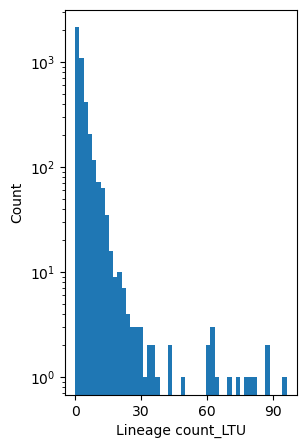

In [162]:
def histogram(dict1, bins=10, x_axis = 'x-axis', y_axis ='Count', ylog=False):
    data1 = list(dict1.values())

    plt.figure(figsize=(3, 5))
    plt.hist(data1, bins=bins, edgecolor=None)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.xticks([0, 30, 60, 90])

    if ylog:
        plt.yscale('log', nonpositive='clip')
    
    plt.savefig(f'hist_{x_ axis[-20:]}.svg', dpi=300, bbox_inches='tight')
    plt.show()

# histogram(cpd2ETUfoldsNum, bins=30, x_axis='Lineage count_ETU', ylog=True)
# histogram(cpd2LTUfoldsNum, bins=50, x_axis='Lineage count_LTU', ylog=True)

In [88]:
# top LTU cpds
{(cpd2name.get(k, 'no name'), k): v for k, v in sorted(cpd2LTUfoldsNum.items(), key=lambda item: item[1], reverse=True)}

{('Mg', 'Z00029'): 156,
 ('Mn', 'Z00030'): 143,
 ('Zinc', 'Z00054'): 117,
 ('ATP', 'C00002'): 96,
 ('Iron', 'Z00015'): 91,
 ('NADPH', 'C00005'): 87,
 ('NADH', 'C00004'): 87,
 ('NAD+', 'C00003'): 81,
 ('NADP+', 'C00006'): 79,
 ('FAD', 'Z00013'): 78,
 ('CO2', 'C00011'): 77,
 ('Orthophosphate', 'C00009'): 73,
 ('Flavoprotein', 'Z00019'): 72,
 ('Divalent Metal (M2)', 'Z00069'): 72,
 ('Cobalt', 'Z00006'): 72,
 ('Calcium', 'Z00055'): 70,
 ('ADP', 'C00008'): 70,
 ('4Fe4S', 'Z00002'): 68,
 ('NAD/NADP', 'Z00032'): 67,
 ('CoA', 'C00010'): 64,
 ('Ammonia', 'C00014'): 63,
 ('Diphosphate', 'C00013'): 63,
 ('FMN', 'Z00014'): 62,
 ('Oxygen', 'C00007'): 62,
 ('Generic FeS', 'Z00063'): 61,
 ('AMP', 'C00020'): 60,
 ('Acetyl-CoA', 'C00024'): 60,
 ('Reduced ferredoxin', 'C00138'): 49,
 ('Nickel', 'Z00034'): 49,
 ('Heme', 'Z00025'): 46,
 ('L-Glutamate', 'C00025'): 44,
 ('Oxidized ferredoxin', 'C00139'): 44,
 ('Acceptor', 'C00028'): 38,
 ('GTP', 'C00044'): 35,
 ('Pyruvate', 'C00022'): 35,
 ('Propanoyl-CoA',

In [87]:
# for 93.8% of cpd, they have ZERO folds that ETU that cpd

print(list(cpd2ETUfoldsNum.values()).count(0))
print(list(cpd2ETUfoldsNum.values()).count(0)/len(cpd2ETUfoldsNum))

4026
0.9380242311276794


In [90]:
# top ETU cpds
{(cpd2name.get(k, 'no name'), k): v for k, v in sorted(cpd2ETUfoldsNum.items(), key=lambda item: item[1], reverse=True)}

{('ATP', 'C00002'): 32,
 ('Oxygen', 'C00007'): 24,
 ('ADP', 'C00008'): 19,
 ('CO2', 'C00011'): 18,
 ('Iron', 'Z00015'): 15,
 ('Orthophosphate', 'C00009'): 13,
 ('Mg', 'Z00029'): 13,
 ('Diphosphate', 'C00013'): 13,
 ('Heme', 'Z00025'): 12,
 ('NADPH', 'C00005'): 11,
 ('Zinc', 'Z00054'): 11,
 ('Nickel', 'Z00034'): 9,
 ('PLP', 'Z00035'): 8,
 ('4Fe4S', 'Z00002'): 8,
 ('Generic FeS', 'Z00063'): 8,
 ('NADH', 'C00004'): 8,
 ('CoA', 'C00010'): 8,
 ('NAD+', 'C00003'): 8,
 ('FAD', 'Z00013'): 7,
 ('Ammonia', 'C00014'): 7,
 ('Hydrogen', 'C00282'): 7,
 ('NADP+', 'C00006'): 7,
 ('Oxidized ferredoxin', 'C00139'): 7,
 ('Reduced ferredoxin', 'C00138'): 7,
 ('AMP', 'C00020'): 6,
 ('L-Glutamate', 'C00025'): 6,
 ('Cobalamin', 'Z00009'): 6,
 ('S-Adenosyl-L-methionine', 'C00019'): 6,
 ('Reduced acceptor', 'C00030'): 5,
 ('Coenzyme F420', 'C00876'): 5,
 ('Formate', 'C00058'): 5,
 ('Flavoprotein', 'Z00019'): 5,
 ('L-Serine', 'C00065'): 5,
 ('Thioredoxin', 'C00342'): 4,
 ('Acceptor', 'C00028'): 4,
 ('L-Methioni

In [91]:
# compare ETU with LTU

# bokeh plot:
remove = ['C00001', 'C00080']  # remove H2O and H+
d1 = {k:v for k,v in cpd2ETUfoldsNum.items() if k not in remove}
d2 = {k:v for k,v in cpd2LTUfoldsNum.items() if k not in remove}

p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)

source = {'x': data1, 'y': data2, 'label': [f"{cpd2name.get(key, 'no name')}" for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = '#ETU folds'
p.yaxis.axis_label = '#LTU folds'
# p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

# 3. fold reuse timing

## rn2ec

In [92]:
rn2ec = csv2dict('../data/assets/rn2ec.csv')

In [93]:
x2rn_ec1 = {}
x2rn_ec2 = {}
for x, rns in x2rn.items():
    ec_list1 = []
    ec_list2 = []
    for rn in rns:
        if rn2ec.get(rn[:6], 0) == 0:  # not in rn2ec
            ec_list1.append('0')
        else:
            ec_list1.append(rn2ec[rn[:6]].split('.')[0])
            ec_list2.append(rn2ec[rn[:6]].split('.')[0] + '.' + rn2ec[rn[:6]].split('.')[1])
    x2rn_ec1[x] = ec_list1
    x2rn_ec2[x] = ec_list2

In [94]:
x2rn_ec1[x].count('1')

0

In [95]:
def drawPie_ec(x, x2rn_ec):
    
    labels = ['0', '1', '2', '3', '4', '5', '6']
    values = [x2rn_ec1[x].count('0'), x2rn_ec1[x].count('1'), x2rn_ec1[x].count('2'), x2rn_ec1[x].count('3'), x2rn_ec1[x].count('4'), x2rn_ec1[x].count('5'), x2rn_ec1[x].count('6')]
    colors = ['gray', '#5B4DB7', '#42ADC7', '#81D152', '#F5F263', '#FF9D4F', '#FF5347']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(values, labels = labels, colors=colors, autopct=lambda p: '{:.0f}% ({:.0f})'.format(p, p * sum(values) / 100), startangle=90, labeldistance=1.05)
    plt.title(f'{x} n={sum(values)}')
    # plt.savefig(f'piechart_cofactor_{title}.svg', dpi=300, bbox_inches='tight')
    plt.show()

In [192]:
# 1: oxidoreductase
# 2. transferease
# 3. Hydrolase
# 4. Lyase
# 5. isomerase
# 6. Translocase

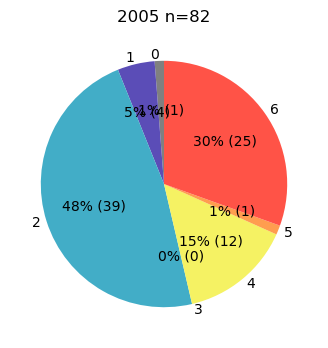

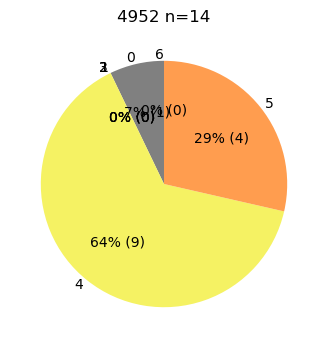

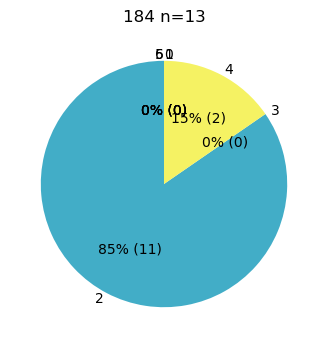

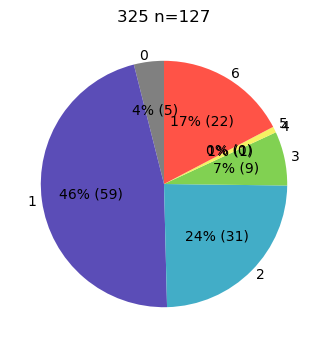

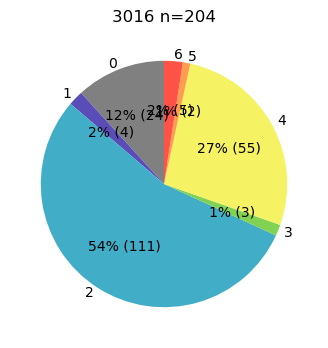

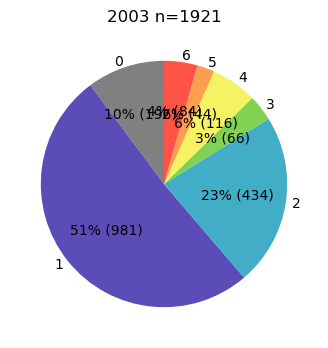

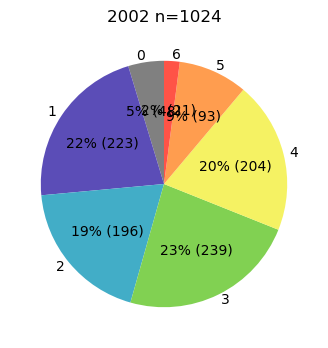

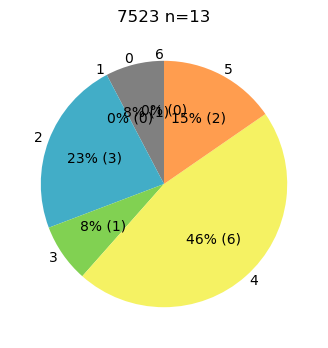

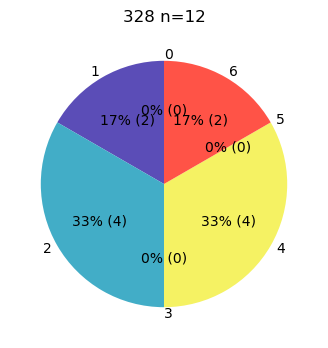

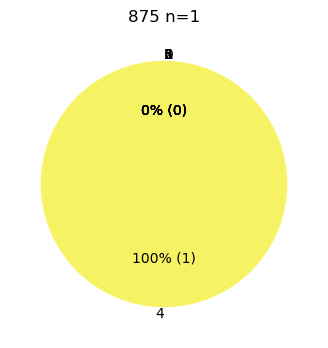

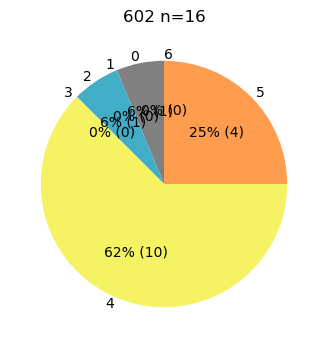

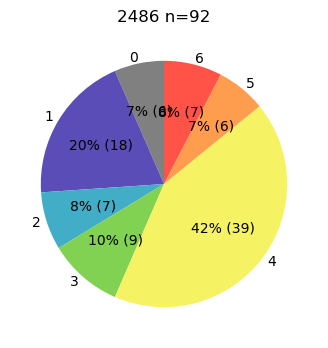

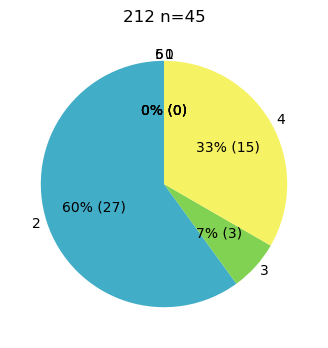

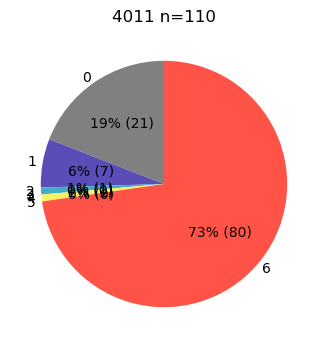

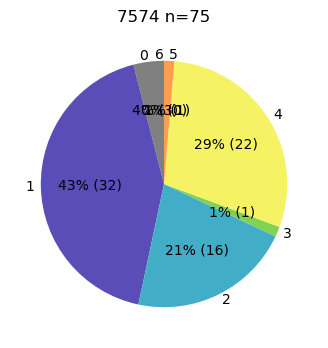

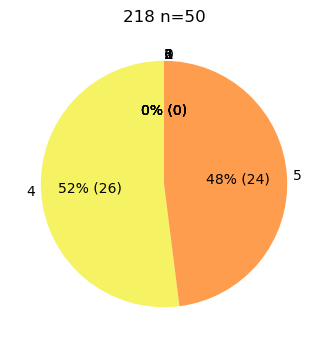

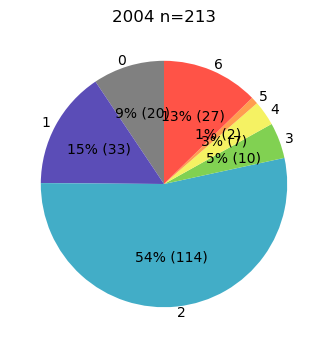

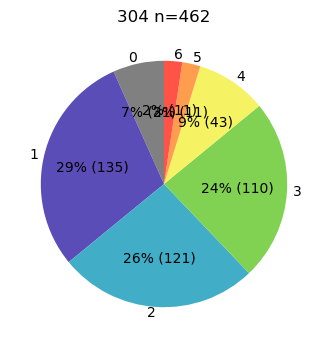

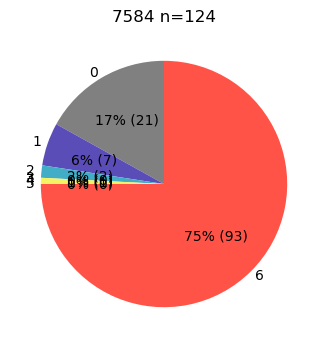

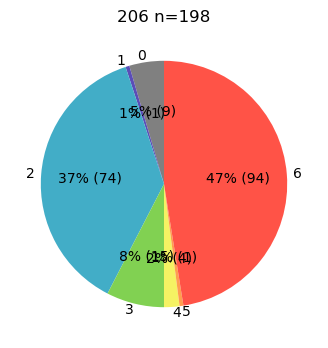

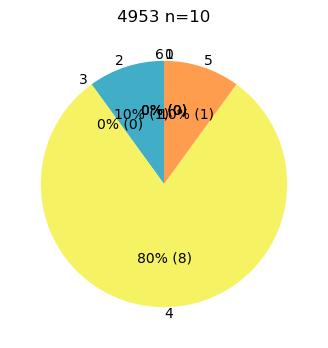

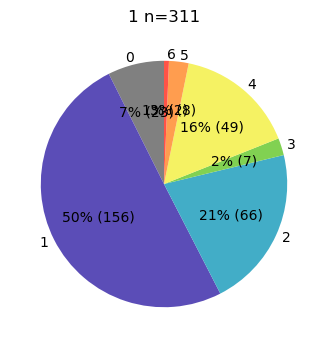

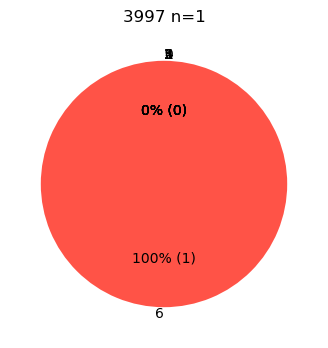

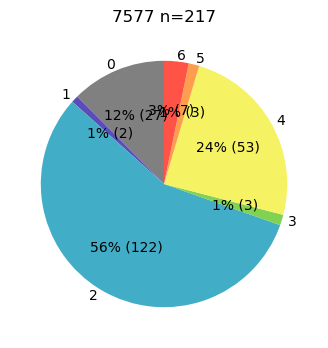

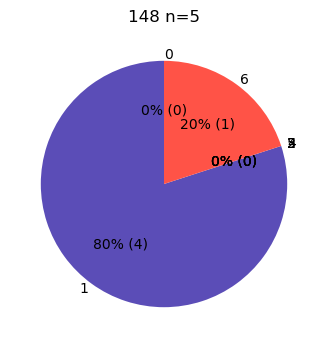

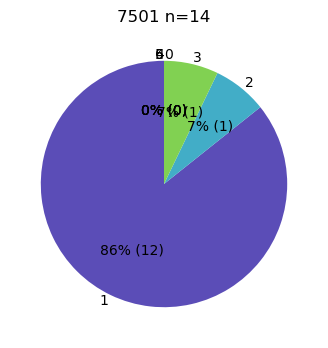

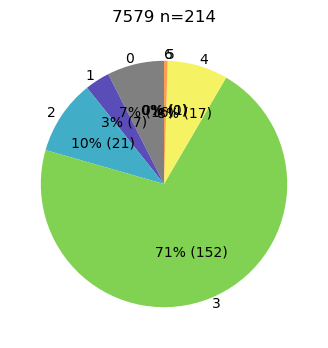

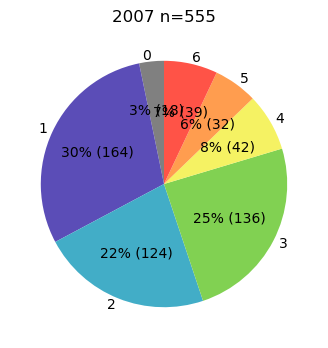

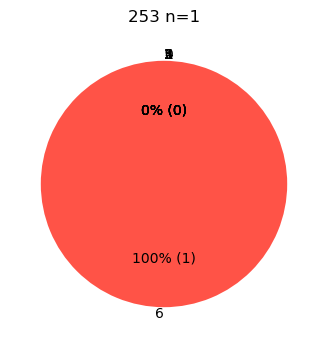

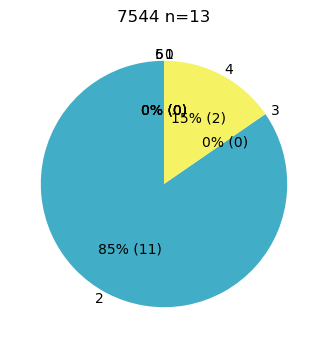

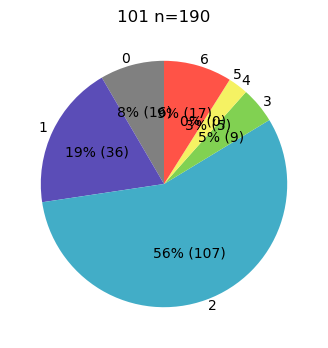

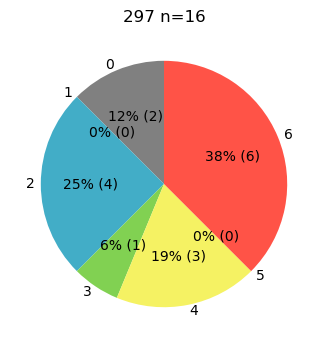

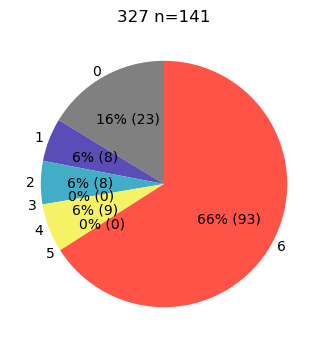

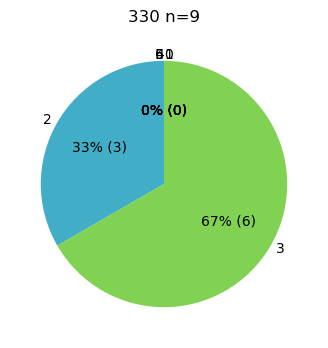

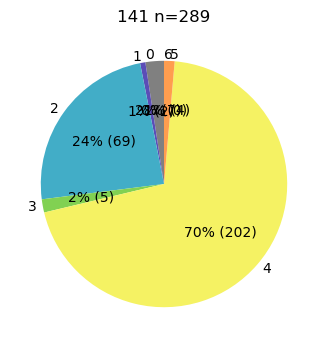

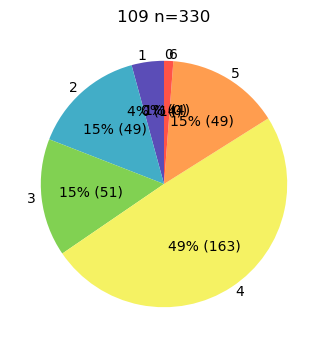

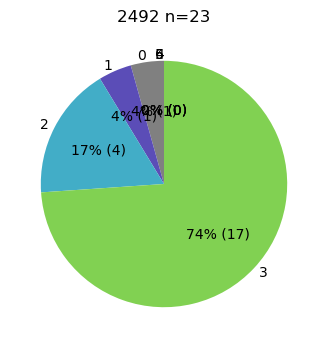

In [96]:
for x in group1:
    drawPie_ec(x, x2rn_ec1)

## back to usage timing

In [194]:
# fastest run
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-08_10-50-55_no_lookahead_preExpansion_C00002_67543.pkl.gz')

In [97]:
# rn2cofactors from rn2cpds

# 7 cofactors
# cofactor_cids = {'Z00035', 'C00002', 'C00003', 'C00010', 'C00019', 'Z00013', 'C00007'}
# 15 cofactors
# cofactor_cids = {'Z00035', 'C00002', 'C00003', 'C00010', 'C00019', 'Z00013', 'C00007', 'C00005', 'Z00009', 'Z00025', 'Z00063', 'Z00002', 'C00139', 'C00876', 'Z00019'}
# 5plus
# cofactor_cids = set([k for k,v in cpd2ETUfoldsNum.items() if v > 4])
# 1plus
cofactor_cids = set([k for k,v in cpd2ETUfoldsNum.items() if v > 0])

rn2cofactors = {}
for rn, cpds in rn2cpds.items():
    rn2cofactors[rn] = set(cpds) & cofactor_cids

In [98]:
rule2fo = {}
for key, value in result.rules_folditer.items():
    if key[1] not in rule2fo.keys():
        rule2fo[key[1]] = [value]
    else:
        rule2fo[key[1]].append(value)

folditer2rules = {}
for key , values in rule2fo.items():
    for value in values:
        if value not in folditer2rules.keys():
            folditer2rules[value] = [key]
        else:
            folditer2rules[value].append(key)
        
x2usage = {x:set() for x in result.folds_folditer.keys()}  # empty dict
x2usage.pop('fold_independent')
x2usage.pop('spontaneous')

for i, rules in folditer2rules.items():
    for rule in rules:
        for x in rule:
            if x in x2usage: # ignore 'fold_independent' and 'spontaneous'
                x2usage[x].add(i)  # don't record multiple usage within one fold_iter
x2usage = {x:sorted(list(s)) for x,s in x2usage.items()}

In [99]:
folditer2reactionRules = {}
for key , fo in result.rules_folditer.items():
        if fo not in folditer2reactionRules.keys():
            folditer2reactionRules[fo] = [key]
        else:
            folditer2reactionRules[fo].append(key)
            
x2usage_ec1 = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_ec1.pop('fold_independent')
x2usage_ec1.pop('spontaneous')
x2usage_ec2 = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_ec2.pop('fold_independent')
x2usage_ec2.pop('spontaneous')
x2usage_cofactor = {x:[] for x in result.folds_folditer.keys()}  # empty dict
x2usage_cofactor.pop('fold_independent')
x2usage_cofactor.pop('spontaneous')

for i, rrs in folditer2reactionRules.items():
    for rr in rrs:
        for x in rr[1]:
            if x in x2usage_ec1: # ignore 'fold_independent' and 'spontaneous'
                x2usage_ec1[x].append([i, rn2ec.get(rr[0], '0.0')[0]])
                x2usage_ec2[x].append([i, rn2ec.get(rr[0], '0.0')[0:3]])
                x2usage_cofactor[x].append([i, rn2cofactors.get(rr[0], set())])

In [100]:
notinrn2ec = []
for rn in result.scope.rns:
    if rn[:6] not in rn2ec.keys():
        notinrn2ec.append(rn)
print(len(notinrn2ec), len(result.scope.rns), len(rn2ec.keys()))

1345 7678 9491


## duration (with new EC2 and new cofactor timing annotated)

In [101]:
x2usage_first_last = {key: [min(values), max(values)] for key, values in x2usage.items()}

In [102]:
# remove folds with duration = 0
single_use_folds = set()
x2usage_first_lastNoSingles = {}

for x , usage in x2usage_first_last.items():
    if usage[1]-usage[0] != 0:
        x2usage_first_lastNoSingles[x] = usage
    else:
        single_use_folds.add(x)
print(len(x2usage_first_last) - len(x2usage_first_lastNoSingles))

180


In [103]:
single_use_folds & set(group1)

{'184', '253', '3997', '7544', '875'}

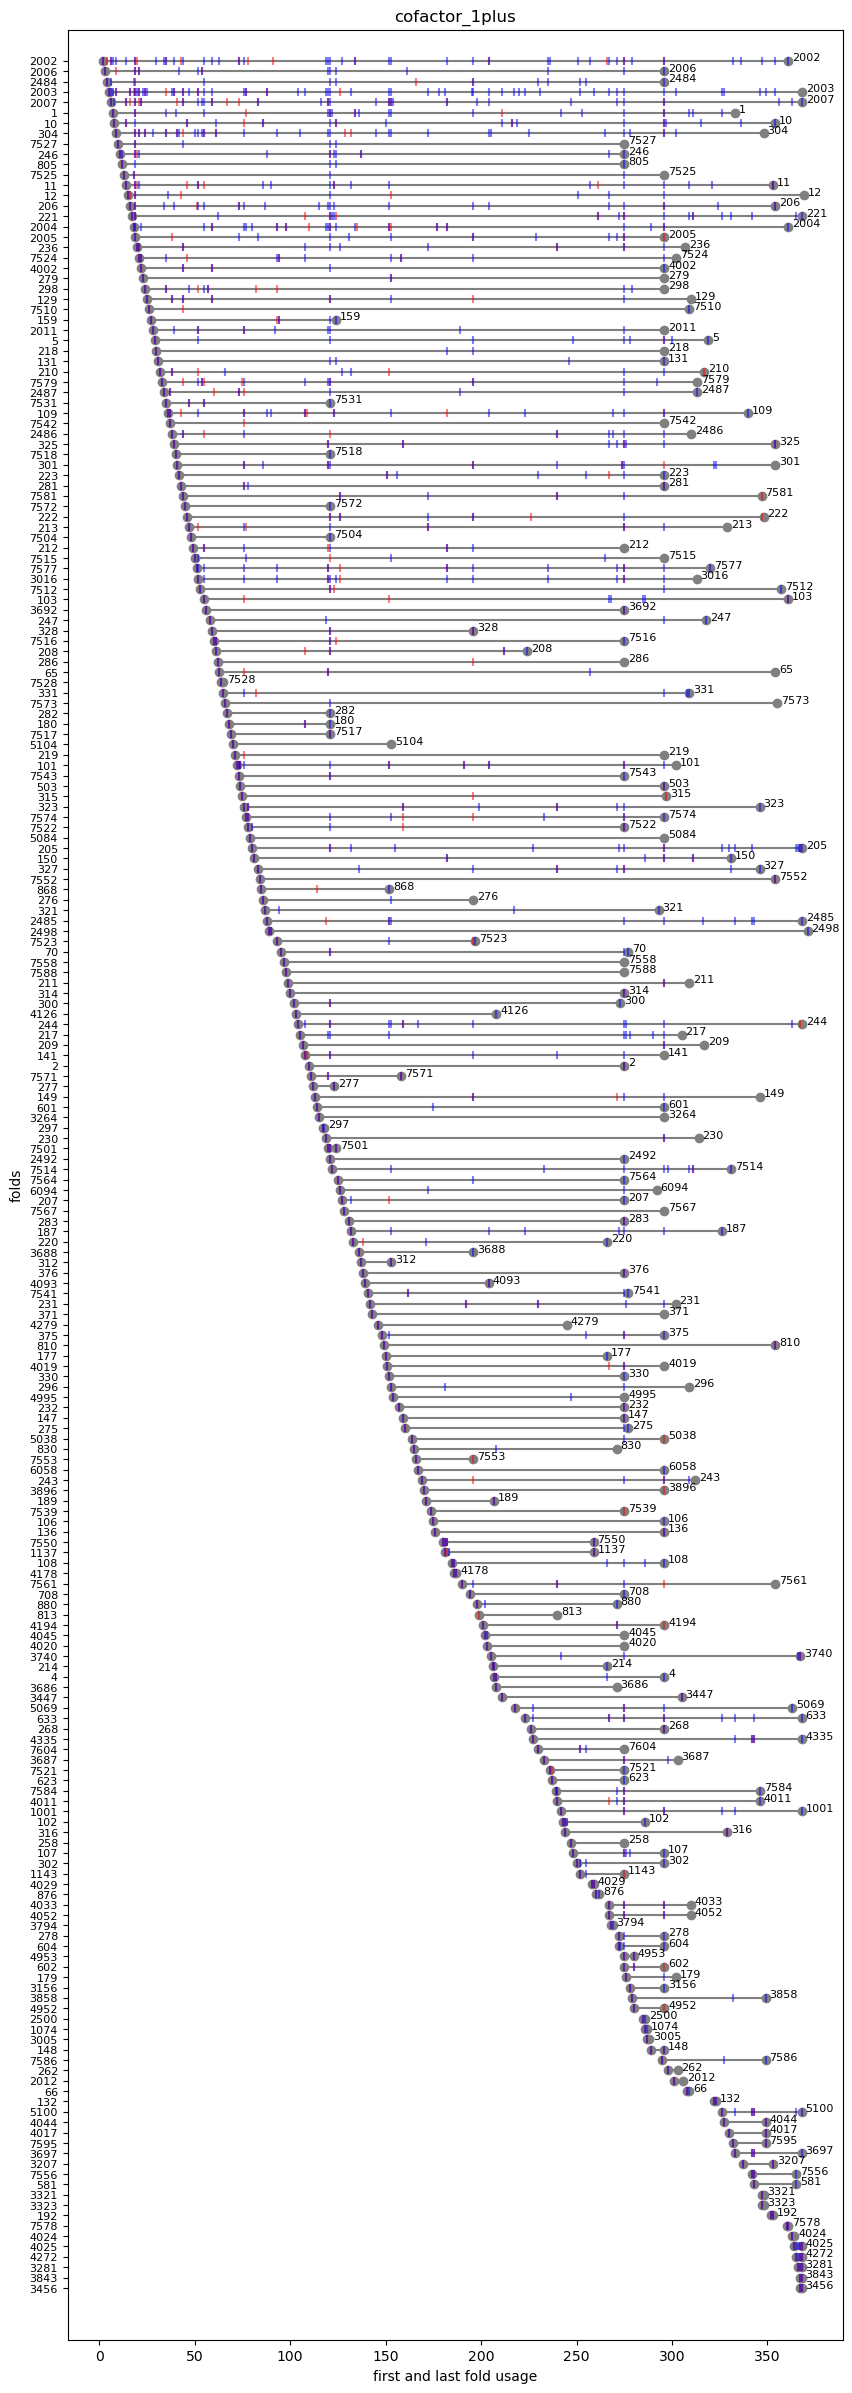

In [104]:
# Preparing data for plotting
data = x2usage_first_lastNoSingles

keys = list(data.keys())
y_positions = range(len(keys))

# color by new ec invention
notches = {}
for fold in x2usage_first_lastNoSingles.keys():
    # accumulate
    fo2ec = {}
    for fo_ec in x2usage_ec2[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    # check iters of new EC2 
    current_ecs = set()
    for fo, ecs in fo2ec.items():
        # if ecs - current_ecs != set() and current_ecs != set():  # ignore first discovery
        if ecs - current_ecs != set():  # do NOT ignore first discovery
            if fold not in notches:
                notches[fold] = [fo]
            else:
                notches[fold].append(fo)
        current_ecs = current_ecs | ecs

# color by new cofactor usage
notches_2 = {}
for fold in x2usage_first_lastNoSingles.keys():
    # accumulate 
    fo2cof = {}
    for fo_cof in x2usage_cofactor[fold]:  # e.g. [2, {'C00002'}]
        if fo_cof[0] not in fo2cof:
            fo2cof[fo_cof[0]] = fo_cof[1]
        else:
            fo2cof[fo_cof[0]] = fo2cof[fo_cof[0]] | fo_cof[1]

    # check iters of new cofactor usage
    current_cofs = set()
    for fo, cofs in fo2cof.items():
        # if cofs - current_cofs != set() and current_cofs != set():  # ignore first discovery
        if cofs - current_cofs != set():  # do NOT ignore first discovery
            if fold not in notches_2:
                notches_2[fold] = [fo]
            else:
                notches_2[fold].append(fo)
        current_cofs = current_cofs | cofs


plt.figure(figsize=(10, 30))

# Plotting lines first
for i, key in enumerate(keys):
    values = data[key]
    plt.plot(values, [key, key], marker='o', color='gray', zorder=1)
    plt.text(values[1] + 2, key, f'{keys[i]}', fontsize=8, zorder=2)

# Adding notches 
for i, key in enumerate(keys):
    notch_positions = notches.get(key, [])  # Get notches for the current key
    for notch in notch_positions:
        plt.scatter(notch, key, color='red', marker='|', zorder=3, alpha=0.5)  # Change marker shape here
# Adding notches_2
for i, key in enumerate(keys):
    notch_positions = notches_2.get(key, [])  # Get notches for the current key
    for notch in notch_positions:
        plt.scatter(notch, key, color='blue', marker='|', zorder=3, alpha=0.5)  # Change marker shape here

# Adding labels
plt.xlabel('first and last fold usage')
plt.ylabel('folds')
plt.yticks(ticks=y_positions, labels=keys, fontsize=8)
plt.ylim([220, -3])
plt.title('cofactor_1plus')

# plt.savefig('fold_usage_duration_ec2_cofactor_1plus.svg', dpi=300, bbox_inches='tight')
plt.show()

## Lazurus (zombie) folds

In [105]:
# remove single-use folds
x2usageNoSingles = {}
for x , usage in x2usage.items():
    if x in x2usage_first_lastNoSingles.keys():
        x2usageNoSingles[x] = usage
print(len(x2usage) - len(x2usageNoSingles))

x2usage_secondLast_last = {}
for key, values in x2usageNoSingles.items():
    x2usage_secondLast_last[key] = [sorted(values)[-2], sorted(values)[-1]]
    
    
def largest_gap(sorted_numbers):    
    # Initialize variables to track the largest gap and the corresponding pair
    largest_gap = 0
    largest_gap_pair = (None, None)
    
    # Compute the differences between consecutive elements
    for i in range(len(sorted_numbers) - 1):
        gap = sorted_numbers[i + 1] - sorted_numbers[i]
        if gap > largest_gap:
            largest_gap = gap
            largest_gap_pair = [sorted_numbers[i], sorted_numbers[i + 1]]
    
    return largest_gap_pair    

x2longestSleep = {}
for key, values in x2usageNoSingles.items():
    x2longestSleep[key] = largest_gap(values)

180


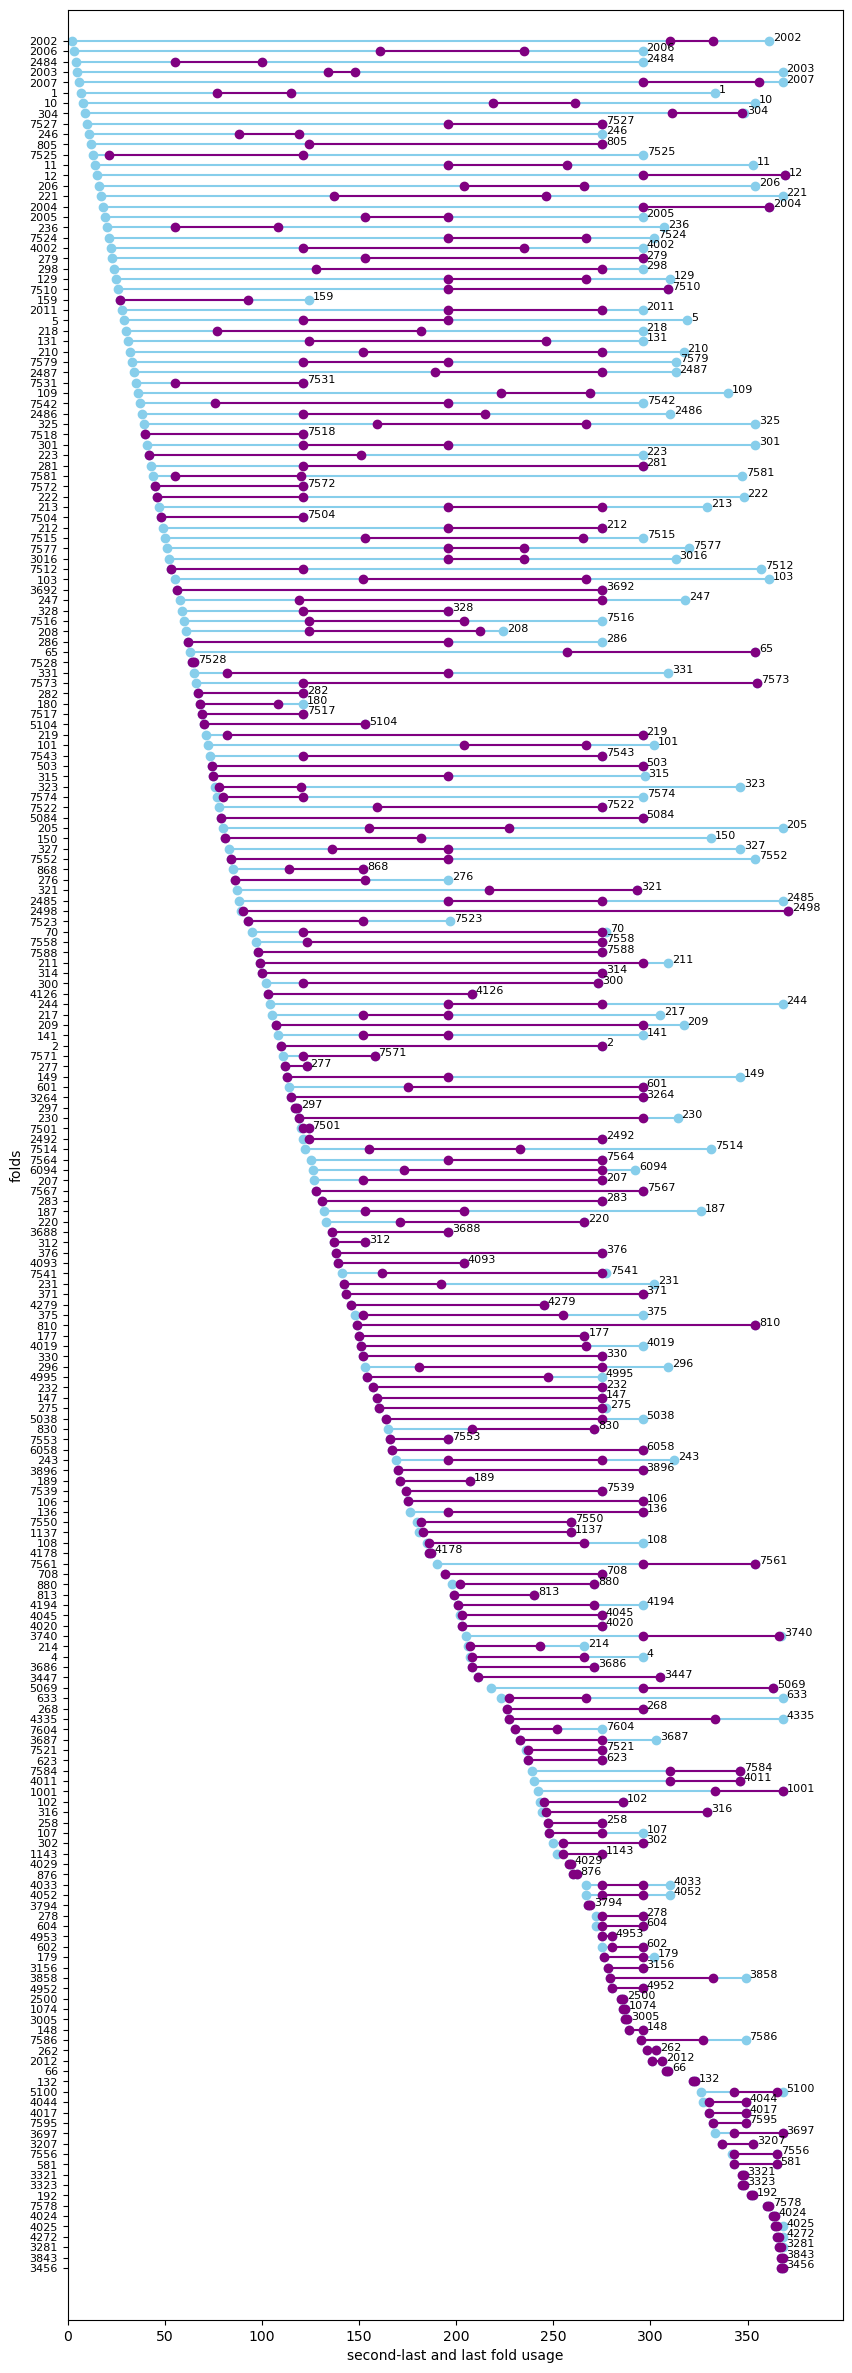

In [106]:
data = x2usage_first_lastNoSingles
keys = list(data.keys())
y_positions = range(len(keys))

plt.figure(figsize=(10, 30))

# Plotting lines
for i, key in enumerate(keys):
    values = data[key]
    plt.plot(values, [key, key], marker='o', color='skyblue', zorder=1)
    plt.text(values[1] + 2, key, f'{keys[i]}', fontsize=8, zorder=3)

# Plotting 'sleep' lines
data = x2longestSleep
keys = list(data.keys())
for i, key in enumerate(keys):
    values = data[key]
    plt.plot(values, [key, key], marker='o', color='purple', zorder=2)
    


# Adding labels
plt.xlabel('second-last and last fold usage')
plt.ylabel('folds')
plt.yticks(ticks=y_positions, labels=keys, fontsize=8)
plt.ylim([220, -3])
plt.xlim([0, 399])

# plt.savefig('lazarus_zombie_longest_sleep.svg', dpi=300, bbox_inches='tight')
plt.show()

## dot per use

In [199]:
x2usageNoSinglesNum = {k:len(v) for k,v in x2usageNoSingles.items()}
for x, reuse in x2usageNoSinglesNum.items():
    print(x, round(reuse/(371-x2foMean[x]), 2), x2name.get(x,x))

2002 0.23 TIM beta/alpha-barrel
2006 0.07 HAD domain-like
2484 0.06 Ribonuclease H-like
2003 0.31 Rossmann-like
2007 0.18 Flavodoxin-like
1 0.09 cradle loop barrel
10 0.09 jelly-roll
304 0.16 Alpha-beta plaits
7527 0.02 7527
246 0.08 Carbon-nitrogen hydrolase-like
805 0.02 805
7525 0.03 7525
11 0.08 Immunoglobulin-like beta-sandwich
12 0.05 Glycosyl hydrolase domain-like
206 0.09 206
221 0.08 beta-Grasp
2004 0.1 P-loop domains-like
2005 0.04 HUP domain-like
236 0.06 GroES-like
7524 0.07 7524
4002 0.03 4002
279 0.01 279
298 0.05 FwdE/GAPDH domain-like
129 0.04 129
7510 0.02 7510
159 0.01 159
2011 0.04 Phosphorylase/hydrolase-like
5 0.04 beta-propeller-like
218 0.02 Enolase-N/ribosomal protein
131 0.02 PDEase-like
210 0.03 Ntn/PP2C
7579 0.06 7579
2487 0.04 The "swivelling" beta/beta/alpha domains
7531 0.01 7531
109 0.05 Repetitive alpha hairpins
7542 0.02 7542
2486 0.05 2486
325 0.05 alpha/beta-Hammerhead/Barrel-sandwich hybrid
7518 0.01 7518
301 0.05 Bacillus chorismate mutase-like
223 

In [211]:
for k, v in dict(collections.OrderedDict(sorted(x2usageNoSinglesNum.items(), key=lambda item: item[1], reverse=True))).items():
    print(v, k, x2foMean[k], x2name.get(k,k))

112 2003 5.0 Rossmann-like
86 2002 2.0 TIM beta/alpha-barrel
66 2007 6.0 Flavodoxin-like
58 304 9.0 Alpha-beta plaits
35 2004 18.0 P-loop domains-like
34 1 7.0 cradle loop barrel
33 10 8.0 jelly-roll
32 206 15.637 206
30 11 14.153 Immunoglobulin-like beta-sandwich
27 2006 3.0 HAD domain-like
27 246 11.0 Carbon-nitrogen hydrolase-like
27 221 15.547 beta-Grasp
25 7524 21.0 7524
25 7577 51.501 7577
22 3016 52.501 3016
21 2484 4.0 Ribonuclease H-like
21 236 20.0 GroES-like
21 7579 33.028 7579
21 205 83.984 205
20 244 102.685 FAD-linked reductases, C-terminal domain-like
18 12 14.121 Glycosyl hydrolase domain-like
18 109 35.506 Repetitive alpha hairpins
17 298 24.0 FwdE/GAPDH domain-like
17 101 78.262 HTH
15 2005 19.0 HUP domain-like
15 2487 32.998 The "swivelling" beta/beta/alpha domains
15 2486 38.938 2486
15 325 39.045 alpha/beta-Hammerhead/Barrel-sandwich hybrid
15 301 42.51 Bacillus chorismate mutase-like
15 323 78.987 323
14 129 25.0 129
14 7581 42.494 7581
14 222 46.936 Thioesterase/

In [195]:
x2class['3016'], x2class['7577']

('a+b', 'a/b')

In [197]:
x2class['244'], x2name['244']

('a+b', 'FAD-linked reductases, C-terminal domain-like')

<Figure size 1000x1700 with 0 Axes>

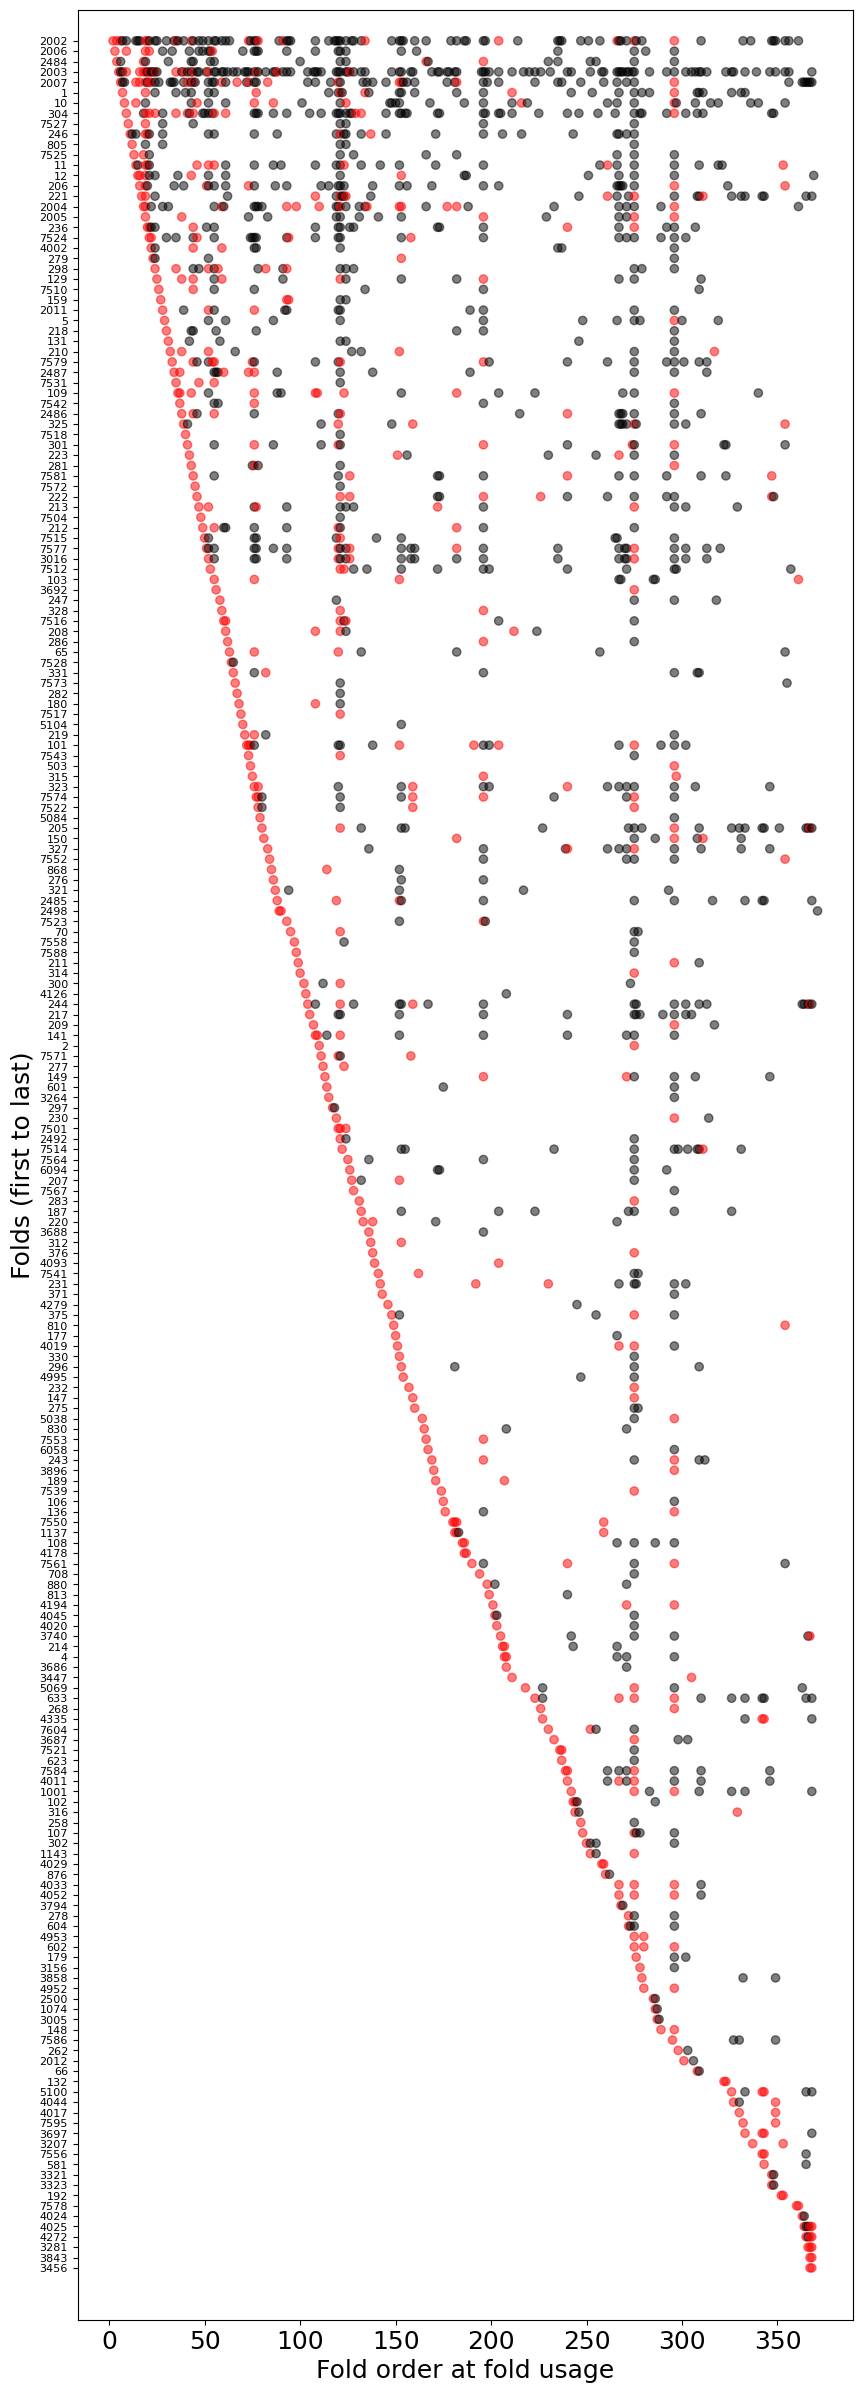

In [191]:
data = x2usageNoSingles

# color by new ec invention
colors = []
for fold in x2usageNoSingles.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec2[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    invention_fo = {}
    current_ecs = set()
    for fo, ecs in fo2ec.items():
        if ecs - current_ecs != set():
            invention_fo[fo] = set(ecs - current_ecs)
        current_ecs = current_ecs | ecs


    for fo in fo2ec.keys():
        if fo in invention_fo:
            colors.append('red')
        else:
            colors.append('black')


keys = list(data.keys())
values = [value for sublist in data.values() for value in sublist]
y_positions = [key for key, sublist in data.items() for _ in sublist]

# Plotting
plt.figure(figsize=(10, 17))
plt.figure(figsize=(10, 30))
plt.scatter(values, y_positions, marker='o', alpha=0.5, color=colors)
plt.gca().invert_yaxis()

# Adding labels
plt.xlabel('Fold order at fold usage', fontsize=18)
plt.ylabel('Folds (first to last)', fontsize=18)

plt.yticks(ticks=list(range(len(keys))), labels=keys, fontsize=8)
plt.ylim([220, -3])

plt.xticks(fontsize=18)

# plt.savefig('fold_usage_ec2.svg', dpi=300, bbox_inches='tight')
plt.show()

## diversity

In [108]:
fo2foldsUsed = {}
for x, usage in x2usage.items():
    for fo in usage:
        if fo not in fo2foldsUsed:
            fo2foldsUsed[fo] = set([x])
        else:
            fo2foldsUsed[fo].add(x) 
fo2foldsUsedNum = {fo:len(foldsUsed) for fo, foldsUsed in fo2foldsUsed.items()}

fo2foldsUsedNum_Full = {}
for i in range(0, max(fo2foldsUsedNum.keys())+1):
    if i not in fo2foldsUsedNum.keys():
        fo2foldsUsedNum_Full[i] = 0
    else:
        fo2foldsUsedNum_Full[i] = fo2foldsUsedNum[i]
print(len(fo2foldsUsedNum_Full))

372


In [109]:
folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
double_injection = []
triple_injection = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double_injection.append(i)
    if len(folds) == 3:
        triple_injection.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

372
372


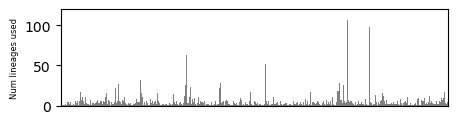

In [135]:
plt.figure(figsize=(5, 1.25))

values = list(fo2foldsUsedNum_Full.values())
x = range(len(values))
plt.bar(x, values, color='gray', alpha=1, width=1.0)

plt.xlim([0, len(folditer2cpdNumFull.values())])
plt.xticks([])
plt.ylim([0, 120])
plt.ylabel('Num lineages used', fontsize=6)

# plt.savefig('folditer_fold-usage.svg', dpi=300, bbox_inches='tight')
plt.show()

### overlay cpd discovery & fold diversity

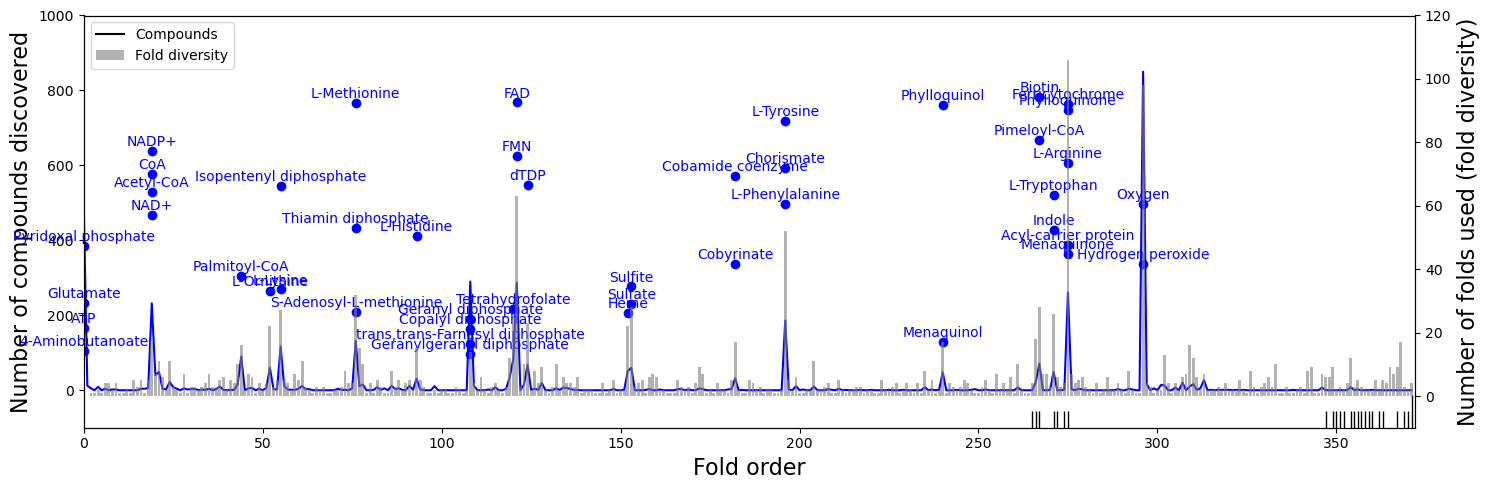

In [178]:
cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer

fig, ax1 = plt.subplots(figsize=(15, 5))

# First plot (line plot)
ax1.plot(folditer2cpdNumFull.values(), color='b', label='Line plot')
ax1.set_ylabel('Number of compounds discovered', fontsize=16)
ax1.set_ylim([-100, 1000])
ax1.set_xlim([0, len(folditer2cpdNumFull.values())])
ax1.set_xlabel('Fold order', fontsize=16)

# Second y-axis for the bar plot
ax2 = ax1.twinx()
values = list(fo2foldsUsedNum_Full.values())
x = range(len(values))
ax2.bar(x, values, color='gray', alpha=0.6, label='Bar plot')
ax2.set_ylabel('Number of folds used (fold diversity)', fontsize=16)
ax2.set_ylim([-10, 120])

# Add cpd annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    ax1.text(value, position, cpd2name[key], ha='center', va='bottom', color='b')
    ax1.scatter(value, position - 5, color='b')

# Add rugplots to ax1 (primary axis)
sns.rugplot(double_injection, height=0.04, color='k', ax=ax1)  # Double fold injection
sns.rugplot(triple_injection, height=0.08, color='k', ax=ax1)  # Triple fold injection

# Custom legend labels
custom_labels = ['Compounds', 'Fold diversity']
handles = lines + bars
ax1.legend(handles, custom_labels, loc='upper left')

plt.tight_layout()
# plt.savefig('folditer_cpds_fold_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()


## folditer vs. new E.C. invention

In [148]:
# include the single usage

notches1 = {}
for fold in x2usage.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec1[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
#         if ecs - current_ecs != set() and current_ecs != set():
        if ecs - current_ecs != set():
            if fold not in notches1:
                notches1[fold] = [fo]
            else:
                notches1[fold].append(fo)
        current_ecs = current_ecs | ecs

notches2 = {}
for fold in x2usage.keys():
    fo2ec = {}
    for fo_ec in x2usage_ec2[fold]:
        if fo_ec[0] not in fo2ec:
            fo2ec[fo_ec[0]] = set(fo_ec[1])
        else:
            fo2ec[fo_ec[0]].add(fo_ec[1])

    current_ecs = set()
    for fo, ecs in fo2ec.items():
#         if ecs - current_ecs != set() and current_ecs != set():
        if ecs - current_ecs != set():
            if fold not in notches2:
                notches2[fold] = [fo]
            else:
                notches2[fold].append(fo)
        current_ecs = current_ecs | ecs

In [149]:
fo2inventions1 = {}
for fold, fos in notches1.items():
    for fo in fos:
        if fo not in fo2inventions1: 
            fo2inventions1[fo] = 1
        else:
            fo2inventions1[fo] += 1

fo2inventions1_Full = {}
for i in range(0, max(fo2inventions1.keys())+1):
    if i not in fo2inventions1.keys():
        fo2inventions1_Full[i] = 0
    else:
        fo2inventions1_Full[i] = fo2inventions1[i]
print(len(fo2inventions1_Full))

fo2inventions2 = {}
for fold, fos in notches2.items():
    for fo in fos:
        if fo not in fo2inventions2: 
            fo2inventions2[fo] = 1
        else:
            fo2inventions2[fo] += 1

fo2inventions2_Full = {}
for i in range(0, max(fo2inventions2.keys())+1):
    if i not in fo2inventions2.keys():
        fo2inventions2_Full[i] = 0
    else:
        fo2inventions2_Full[i] = fo2inventions2[i]
print(len(fo2inventions2_Full))

372
372


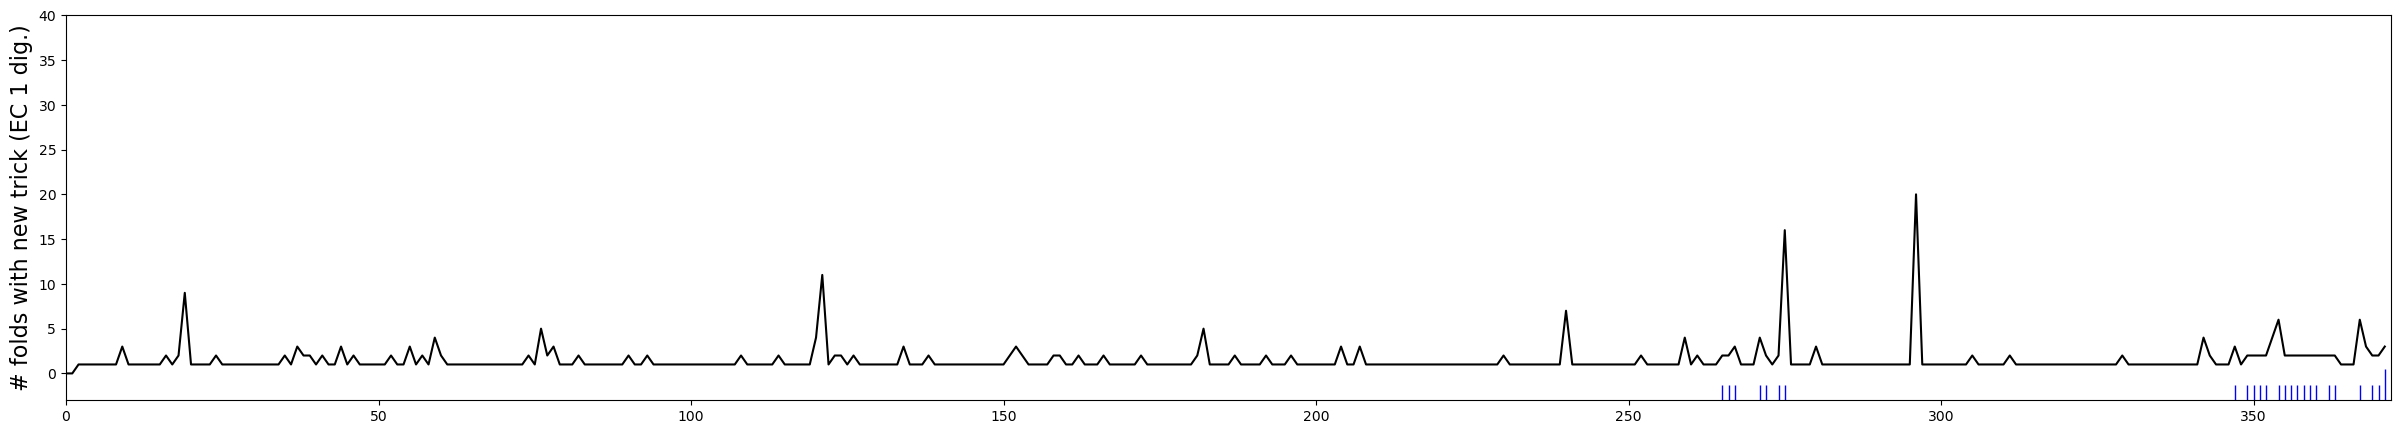

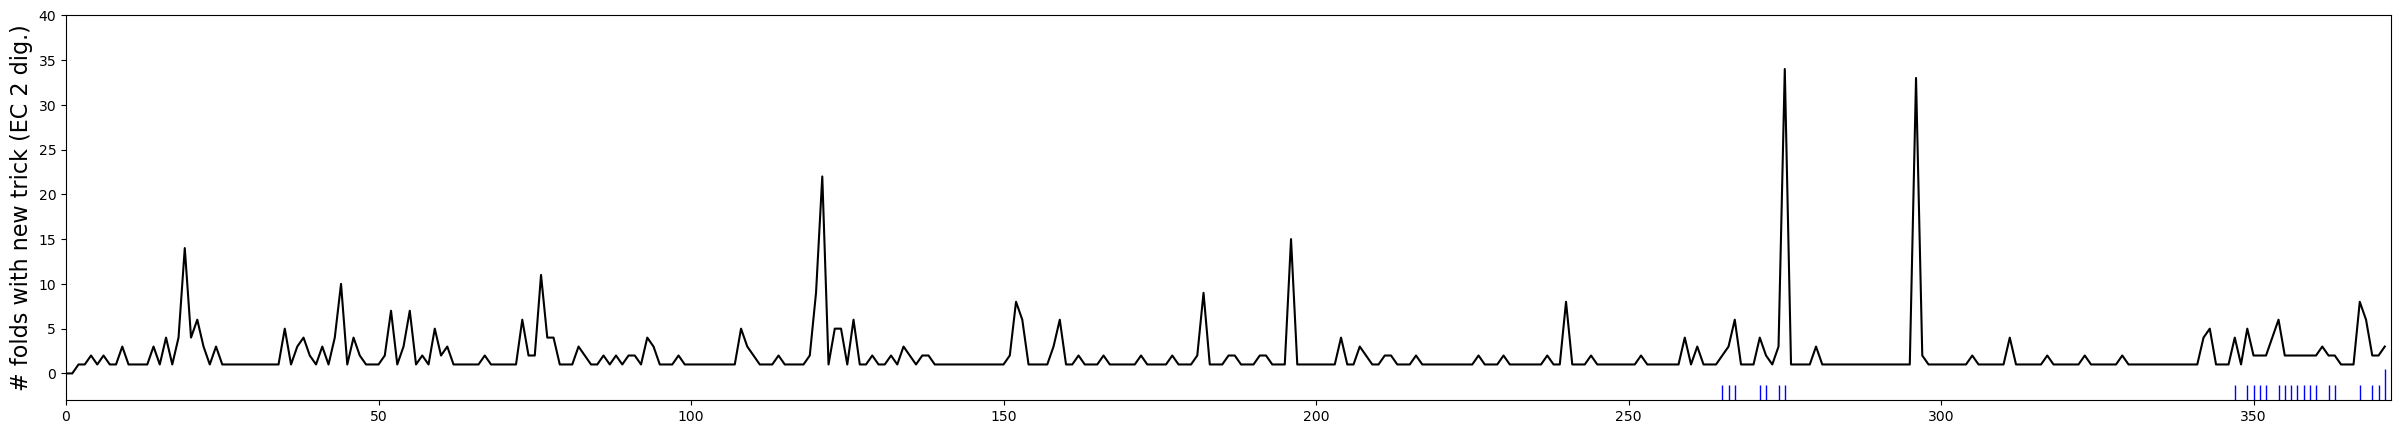

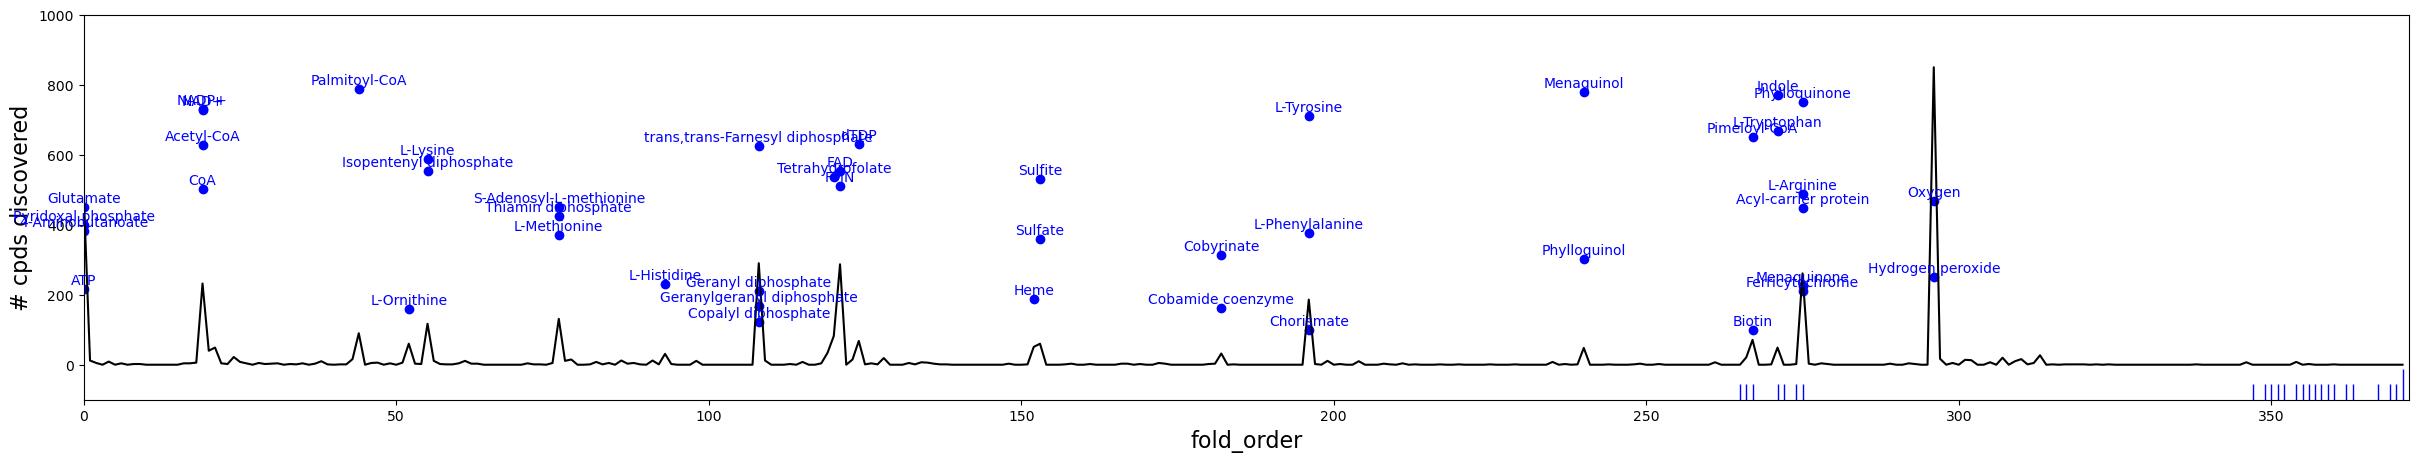

In [150]:
plt.figure(figsize=(30, 5))
plt.plot(fo2inventions1_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, len(folditer2cpdNumFull.values())])
plt.ylim([-3,40])
plt.ylabel('# folds with new trick (EC 1 dig.)', fontsize=16)
# plt.savefig('folditer_fold_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()



plt.figure(figsize=(30, 5))
plt.plot(fo2inventions2_Full.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, len(folditer2cpdNumFull.values())])
plt.ylim([-3,40])
plt.ylabel('# folds with new trick (EC 2 dig.)', fontsize=16)
# plt.savefig('folditer_fold_diversity.svg', dpi=300, bbox_inches='tight')
plt.show()



# compare with cpd discovery
cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, len(folditer2cpdNumFull.values())])
plt.ylim([-100, 1000])
plt.xlabel('fold_order', fontsize=16)
plt.ylabel('# cpds discovered', fontsize=16)
# plt.savefig('folditer_cpds_annotated_2.svg', dpi=300, bbox_inches='tight')
plt.show()

## #usage vs. #rules - scatter

In [151]:
x2rulesNum_scope = csv2dict('../data/assets/xgroup2/xgroup2rulesNum_scope.csv')

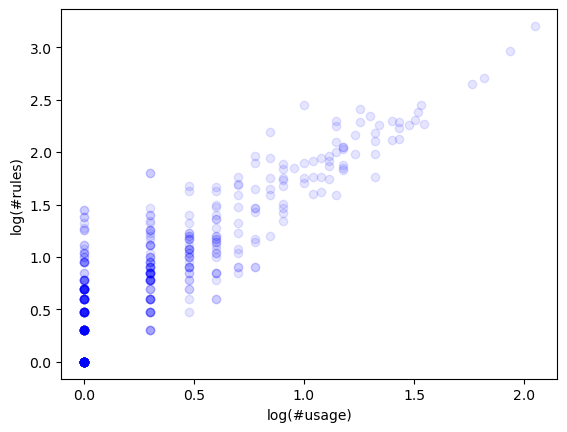

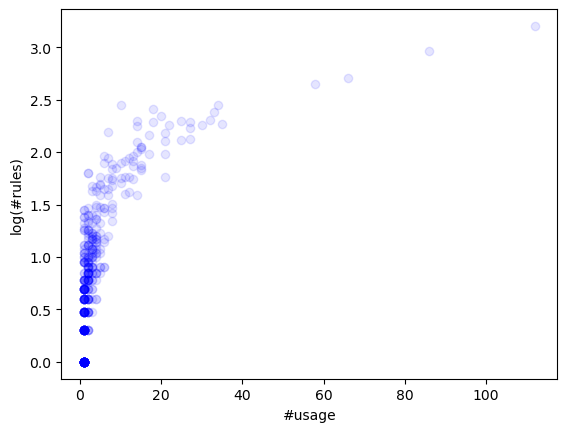

In [152]:
# some folds with many rules are used in one fold_order!

x2usageNum = {x:len(usage) for x, usage in x2usage.items()}
loglog(x2usageNum, x2rulesNum_scope, 'log(#usage)', 'log(#rules)')
ylog(x2usageNum, x2rulesNum_scope, '#usage', 'log(#rules)')

In [153]:
from matplotlib.cm import ScalarMappable

d1 = x2usageNum
d2 = x2rulesNum_scope

# output_file("mean_folditer_vs_escore_RUN.html")
p = figure(width=800, height=800)

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)
data1 = np.log10(data1)
data2 = np.log10(data2)

# Use a red colormap
colormap = plt.cm.Blues
scalar_mappable = ScalarMappable(cmap=colormap)
colors = scalar_mappable.to_rgba([x2ds[x] for x in valid_keys if x in x2ds])
colors = ['#ff7f0e' if key in group1 else '#1f77b4' for key in valid_keys]

source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in valid_keys], 'ds': [x2ds[key] for key in valid_keys], 
          'color': colors, 'num_rules': [str(x2rulesNum_scope[key]) for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, color='color', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label"), ("#rules", "@num_rules"), ("ds", "@ds")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = '#usage'
p.yaxis.axis_label = '#rules_scope'
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [154]:
single_use = [x for x in x2usageNum.keys() if x2usageNum[x] == 1]
len(single_use)

180

In [155]:
print(single_use)

['4004', '4021', '3699', '4081', '7589', '7529', '239', '7560', '3691', '62', '7534', '7500', '7580', '3883', '266', '133', '7509', '2493', '3754', '7554', '172', '3257', '3847', '629', '873', '270', '7549', '7520', '307', '387', '3599', '6113', '3654', '3651', '3292', '4262', '7536', '3086', '355', '377', '611', '812', '3117', '3009', '284', '875', '164', '582', '7513', '4237', '650', '3001', '305', '64', '197', '3685', '4022', '7562', '2496', '237', '235', '1114', '154', '4111', '253', '6096', '4295', '842', '1055', '7551', '285', '6075', '1077', '3076', '632', '7540', '814', '1144', '5067', '525', '4049', '319', '5103', '309', '185', '920', '378', '4018', '7587', '2008', '1119', '184', '7544', '4114', '2010', '590', '3052', '7568', '3371', '139', '73', '69', '313', '374', '6051', '199', '303', '3997', '146', '867', '914', '257', '7', '3249', '6166', '557', '158', '4294', '9', '640', '3978', '4983', '4110', '6174', '608', '620', '4159', '6', '4161', '3752', '3294', '196', '911', '241

In [156]:
set(group1) & set(single_use)

{'184', '253', '3997', '7544', '875'}

In [157]:
for x in set(group1) & set(single_use):
    print(x, x2rulesNum_scope[x])

7544 11
253 1
184 11
875 1
3997 1


In [158]:
set(group1) & singleton

{'253', '4011', '7584'}

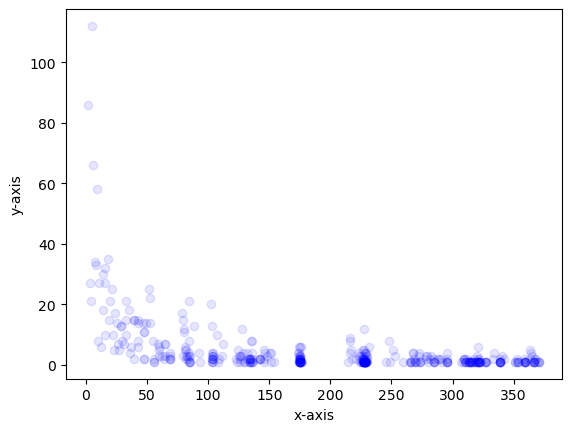

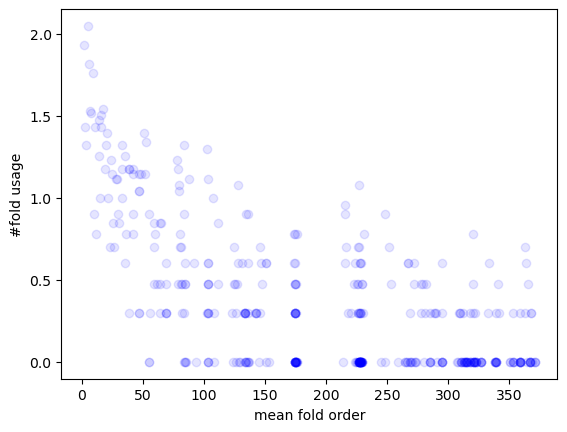

In [159]:
scatter(x2foMean, x2usageNum)
ylog(x2foMean, x2usageNum, 'mean fold order', '#fold usage')

# Do first-reactions always have the fold that was injected at that cumiter?

In [160]:
# The answer is - YES

# for run in df_cpds_folditer.columns:
#     cumiter2rules = {}
#     for rule, i in df_rules_cumiter[run].items():
#         if i not in cumiter2rules:
#             cumiter2rules[i] = [eval(rule)]  # convert string into tuple with 'eval'
#         else:
#             cumiter2rules[i].append(eval(rule))
    
#     cumiter2folds = {}
#     for fold, cumiter in df_folds_cumiter[run].items():
#         if cumiter not in cumiter2folds:
#             cumiter2folds[cumiter] = [fold]
#         else:
#             cumiter2folds[cumiter].append(fold)
    
#     for i, rnRules in cumiter2rules.items():
#         if i in cumiter2folds.keys():  # check cumiters with fold injection
#             folds = cumiter2folds[i]
#             for rnRule in rnRules:
#                 for x in folds:  # check all folds (multi-injection possible)
#                     if x not in rnRule[1]:
#                         print(f'{x} not in rule: {rnRule[1]}')

# Only use rules with one fold (solo domain vs. multi-domain rules)

In [258]:
rn2rules_solo = {}
for rn, rules in rn2rules.items():
    new_rules = set()
    for rule in rules:
        if len(rule) == 1:
            new_rules.add(rule)
    rn2rules_solo[rn] = new_rules

# remove reactions with no solo rules
rn2rules_solo = {k:v for k,v in rn2rules_solo.items() if len(v) > 0}

In [ ]:
len(rns_scope)

In [254]:
len(rn2rules), len(set(rn2rules.keys()) & set(rns_scope))

(12872, 5730)

In [253]:
len(rn2rules_solo), len(set(rn2rules_solo.keys()) & set(rns_scope))

(8715, 3819)

In [259]:
rn2rules_solo

{'R01015': {frozenset({'2002'})},
 'R01070': {frozenset({'304'}), frozenset({'2002'})},
 'R01786': {frozenset({'2484'})},
 'R02740': {frozenset({'2007'}), frozenset({'2002'}), frozenset({'10'})},
 'R09084': {frozenset({'2003'})},
 'R02189': {frozenset({'2484'})},
 'R09085': {frozenset({'2003'})},
 'R01518': {frozenset({'7525'})},
 'R00431': {frozenset({'2004'})},
 'R00726': {frozenset({'2004'})},
 'R00341': {frozenset({'2004'})},
 'R04780': {frozenset({'246'}), frozenset({'304'})},
 'R01827': {frozenset({'2002'})},
 'R02739': {frozenset({'2007'}), frozenset({'2002'}), frozenset({'10'})},
 'R10907': {frozenset({'2003'})},
 'R01056': {frozenset({'7560'})},
 'R01529': {frozenset({'2002'})},
 'R02035': {frozenset({'2003'}), frozenset({'5'})},
 'R01049': {frozenset({'7573'})},
 'R05605': {frozenset({'2002'})},
 'R00709': {frozenset({'7510'})},
 'R00268': {frozenset({'7510'})},
 'R00267': {frozenset({'7510'})},
 'R00351': {frozenset({'172'}), frozenset({'2002'})},
 'R01899': {frozenset({'751

In [290]:
def getCpdUsingFolds(cpd, direct_cpd_rn_set):
    
    # get all reactions that use given cpd
    if cpd.startswith('C'):
        # just use one run to get using/producing reactions
        run = '87452'
        using, both, producing = getUsingProducingRns(run, cpd, direct_cpd_rn_set)
    
        my_rns = (set(using) | set(both.keys())) & set(rn2rules_solo.keys())  # use + both in solo

    else:
        my_rns = direct_cpd_rn_set & set(rn2rules_solo.keys())
    
    
    cpd_using_folds = set() 
    for rn in my_rns:
        for fold in rn2rules_solo[rn]:  # for each fold
            cpd_using_folds.update(fold)  # Add elements from the fold
    
    if 'spontaneous' in cpd_using_folds:
        cpd_using_folds.remove('spontaneous')
    
    return cpd_using_folds



cpd = 'Z00009'
direct_cpd_rn_set = getDirectRns(cpd) & set(result.scope.rns)
cuf = getCpdUsingFolds(cpd, direct_cpd_rn_set)
len(cuf)

2

In [287]:
rn2direction.pop('\ufeffC00404_syn')
rn2direction['C00404_syn'] = 'forward'

In [291]:
cpd2foldsSolo = {}
for cpd in result.scope.cpds:
    direct_cpd_rn_set = getDirectRns(cpd) & set(result.scope.rns)
    cpd2foldsSolo[cpd] = getCpdUsingFolds(cpd, direct_cpd_rn_set)

In [292]:
cpd2foldsSolo

{'C03217': set(),
 'C00395': {'210', '247'},
 'Z00017': set(),
 'C05945': set(),
 'C18050': {'2006', '7512'},
 'C22008': {'149'},
 'C03035': {'222'},
 'C05608': {'2003'},
 'C01455': {'374'},
 'C20576': set(),
 'C21307': {'149'},
 'C00933': {'7579'},
 'C05111': set(),
 'C12632': set(),
 'C04924': set(),
 'C05202': {'2003'},
 'C21780': {'7512'},
 'C02916': set(),
 'C05772': {'7550'},
 'C00133': {'2003', '213', '307'},
 'C20966': set(),
 'C01087': set(),
 'C00356': {'2002', '2486', '7527', '7581'},
 'C12305': {'2003'},
 'C19739': {'101'},
 'C21727': {'141'},
 'C22006': {'2003'},
 'C00331': {'2003'},
 'C14045': set(),
 'C04137': {'129'},
 'C05764': {'2002', '2003', '222', '7581'},
 'C20410': {'2003'},
 'C02890': set(),
 'C20625': {'7516'},
 'C17210': set(),
 'C22261': {'2003'},
 'C06398': {'2003'},
 'C16488': {'2002'},
 'C00407': {'10', '149'},
 'C05933': {'2006', '262', '3249'},
 'C00922': {'286'},
 'C00878': set(),
 'Z00052': {'374'},
 'C02666': {'101', '149', '2003', '7524'},
 'C05647':

In [293]:
# dict2csv(cpd2foldsSolo, '../data/assets/cpd2foldsSolo.csv')